In [193]:
## Nike product EDA

In [194]:
## Each row represents daily aggregated sales for a specific product,region, retailer, and sales method.

In [195]:
## data aggregation based on brand-country-month

In [196]:
import seaborn as sns
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

# you must complete this function to load the data
def load_data(address):
    df = pd.DataFrame(pd.read_csv(address))
    return df
df = load_data('data/cost-of-living.csv')
top_50_country_names = df['country'].value_counts().head(54).index.tolist()
filtered_df = df[df['country'].isin(top_50_country_names)]
filtered_df.head()



,Unnamed: 0,city,country,x1,x2,x3,x4,x5,x6,x7,...,x47,x48,x49,x50,x51,x52,x53,x54,x55,data_quality
0,0,Delhi,India,4.90,22.04,4.28,1.84,3.67,1.78,0.48,...,36.26,223.87,133.38,596.16,325.82,2619.46,1068.90,586.35,7.96,1
1,1,Shanghai,China,5.59,40.51,5.59,1.12,4.19,3.96,0.52,...,121.19,1080.07,564.30,2972.57,1532.23,17333.09,9174.88,1382.83,5.01,1
2,2,Jakarta,Indonesia,2.54,22.25,3.50,2.02,3.18,2.19,0.59,...,80.32,482.85,270.15,1117.69,584.37,2694.05,1269.44,483.19,9.15,1
3,3,Manila,Philippines,3.54,27.40,3.54,1.24,1.90,2.91,0.93,...,61.82,559.52,281.78,1754.40,684.81,3536.04,2596.44,419.02,7.80,1
4,4,Seoul,South Korea,7.16,52.77,6.03,3.02,4.52,3.86,1.46,...,108.30,809.83,583.60,2621.05,1683.74,21847.94,10832.90,2672.23,3.47,1


In [197]:
feature_names = [
    'Milk', 'Bread', 'Rice', 'Eggs', 'Local Cheese',
    'Chicken Fillets', 'Beef Round', 'Apples', 'Banana',
    'Oranges', 'Tomato', 'Potato', 'Onion', 'Lettuce',
    'Water', 'Bottle of Wine', 'Domestic Beer', 'Imported Beer'
]
grocery_cols = [f'x{i}' for i in range(9, 27)]
identity_cols = ['city', 'country']

grocery_df = filtered_df[identity_cols + grocery_cols].copy()
grocery_cols_features = {f'x{i}': name for i, name in zip(range(9, 27), feature_names)}
grocery_df = grocery_df.rename(columns=grocery_cols_features)
grocery_df.head(54)

,city,country,Milk,Bread,Rice,Eggs,Local Cheese,Chicken Fillets,Beef Round,Apples,Banana,Oranges,Tomato,Potato,Onion,Lettuce,Water,Bottle of Wine,Domestic Beer,Imported Beer
0,Delhi,India,0.73,0.51,0.88,1.01,4.32,3.79,5.57,1.80,0.75,1.01,0.60,0.36,0.41,0.70,0.36,9.79,1.53,2.51
1,Shanghai,China,2.68,2.57,1.18,2.17,18.01,4.67,12.79,2.22,1.55,2.11,1.47,0.82,1.02,0.82,0.62,13.97,0.91,1.93
2,Jakarta,Indonesia,1.28,1.21,0.83,1.70,6.66,3.46,8.32,2.80,1.52,2.08,1.24,1.35,2.10,1.13,0.42,20.66,2.06,3.18
3,Manila,Philippines,1.63,1.19,0.89,1.73,5.06,4.19,6.64,2.66,1.42,2.95,1.42,1.76,1.75,1.36,0.65,8.84,1.15,1.55
4,Seoul,South Korea,2.13,2.78,3.66,4.02,11.13,10.62,40.41,6.79,3.70,6.40,6.36,3.86,2.81,2.40,1.06,15.08,2.10,2.49
5,Bangkok,Thailand,1.61,1.86,1.44,1.96,15.94,3.00,11.51,2.83,1.43,1.83,1.42,1.40,1.20,1.16,0.46,19.66,1.61,2.83
6,Kolkata,India,0.63,0.37,0.69,0.91,4.85,3.03,6.36,1.88,0.65,1.21,0.64,0.40,0.44,0.37,0.34,9.49,1.78,2.90
7,Guangzhou,China,1.88,1.60,1.01,1.68,8.83,3.70,11.53,1.98,1.41,1.79,1.28,0.72,0.98,0.48,0.50,11.17,0.93,2.02
8,Mumbai,India,0.74,0.50,0.84,0.97,5.81,3.68,6.19,2.10,0.69,1.34,0.59,0.44,0.45,0.64,0.35,9.79,2.26,3.63
9,Beijing,China,1.97,2.07,1.20,1.85,12.66,3.94,12.56,1.95,1.84,1.91,1.45,0.88,0.97,0.85,0.63,11.87,1.01,2.40


In [198]:
grocery_df.shape

(4117, 20)

In [199]:
def count_the_missing_values_of_each_column(df):
    missing_values_series = df.isnull().sum()
    return missing_values_series

missing_values_series = count_the_missing_values_of_each_column(grocery_df)
print(missing_values_series)

city                 0
country              0
Milk               323
Bread              357
Rice               277
Eggs               456
Local Cheese       386
Chicken Fillets    495
Beef Round         489
Apples             296
Banana             303
Oranges            353
Tomato             396
Potato             363
Onion              350
Lettuce            386
Water              313
Bottle of Wine     362
Domestic Beer      617
Imported Beer      536
dtype: int64


In [200]:
grocery_df.nunique().any()

np.True_

In [201]:
grocery_df.duplicated().any()

np.False_

In [202]:
country_counts = grocery_df['country'].value_counts()
print (country_counts)

country
United States     1074
Italy              185
India              167
Brazil             166
United Kingdom     161
Germany            147
Russia             139
Canada             120
France             114
China              105
Spain               88
Mexico              87
Philippines         77
Japan               75
Poland              67
Australia           64
Turkey              61
Netherlands         55
Romania             53
Portugal            52
Ukraine             45
Hungary             45
Switzerland         43
Indonesia           40
Pakistan            39
Belgium             39
Thailand            38
Iran                37
Greece              36
Serbia              35
South Africa        34
Israel              34
Slovakia            34
Malta               34
Algeria             33
Nigeria             32
Morocco             32
Bulgaria            30
Sweden              30
South Korea         29
Argentina           27
Chile               27
Finland             27
Slo

In [203]:
grocery_df.shape

(4117, 20)

# #Univariate Analysis

In [204]:
grocery_df.describe()

,Milk,Bread,Rice,Eggs,Local Cheese,Chicken Fillets,Beef Round,Apples,Banana,Oranges,Tomato,Potato,Onion,Lettuce,Water,Bottle of Wine,Domestic Beer,Imported Beer
count,3794.000000,3760.000000,3840.000000,3661.000000,3731.000000,3622.000000,3628.000000,3821.000000,3814.000000,3764.00000,3721.000000,3754.000000,3767.000000,3731.00000,3804.000000,3755.000000,3500.000000,3581.000000
mean,1.097254,1.680322,2.291404,2.356539,9.676776,7.382543,12.181855,2.791630,1.539253,2.42317,2.670685,1.624744,1.569748,1.23874,1.018249,8.728301,1.690646,2.323854
std,0.424083,1.097105,1.713528,1.056397,4.826982,4.638567,7.292273,1.826297,0.709196,1.72365,1.824119,1.226562,1.124878,0.68469,0.705024,4.440749,0.922173,1.092187
min,0.320000,0.050000,0.240000,0.100000,0.900000,1.220000,1.430000,0.270000,0.220000,0.22000,0.120000,0.110000,0.110000,0.08000,0.110000,0.360000,0.250000,0.350000
25%,0.810000,0.870000,1.060000,1.580000,6.410000,4.030000,7.597500,1.490000,1.110000,1.21000,1.270000,0.790000,0.780000,0.74000,0.480000,5.190000,1.000000,1.500000
50%,1.030000,1.390000,1.760000,2.200000,8.940000,6.390000,10.980000,2.340000,1.420000,1.98500,2.250000,1.260000,1.240000,1.06000,0.785000,8.050000,1.470000,2.130000
75%,1.260000,2.330000,2.990000,2.990000,12.080000,9.415000,14.680000,3.690000,1.810000,3.12500,3.780000,2.180000,2.170000,1.66000,1.490000,11.910000,2.200000,2.950000
max,4.830000,8.810000,15.430000,9.650000,48.470000,44.090000,95.110000,17.330000,8.050000,15.08000,17.640000,10.830000,8.820000,5.36000,5.000000,35.000000,6.100000,8.050000


<Axes: title={'center': 'Country Entry Count'}, ylabel='country'>

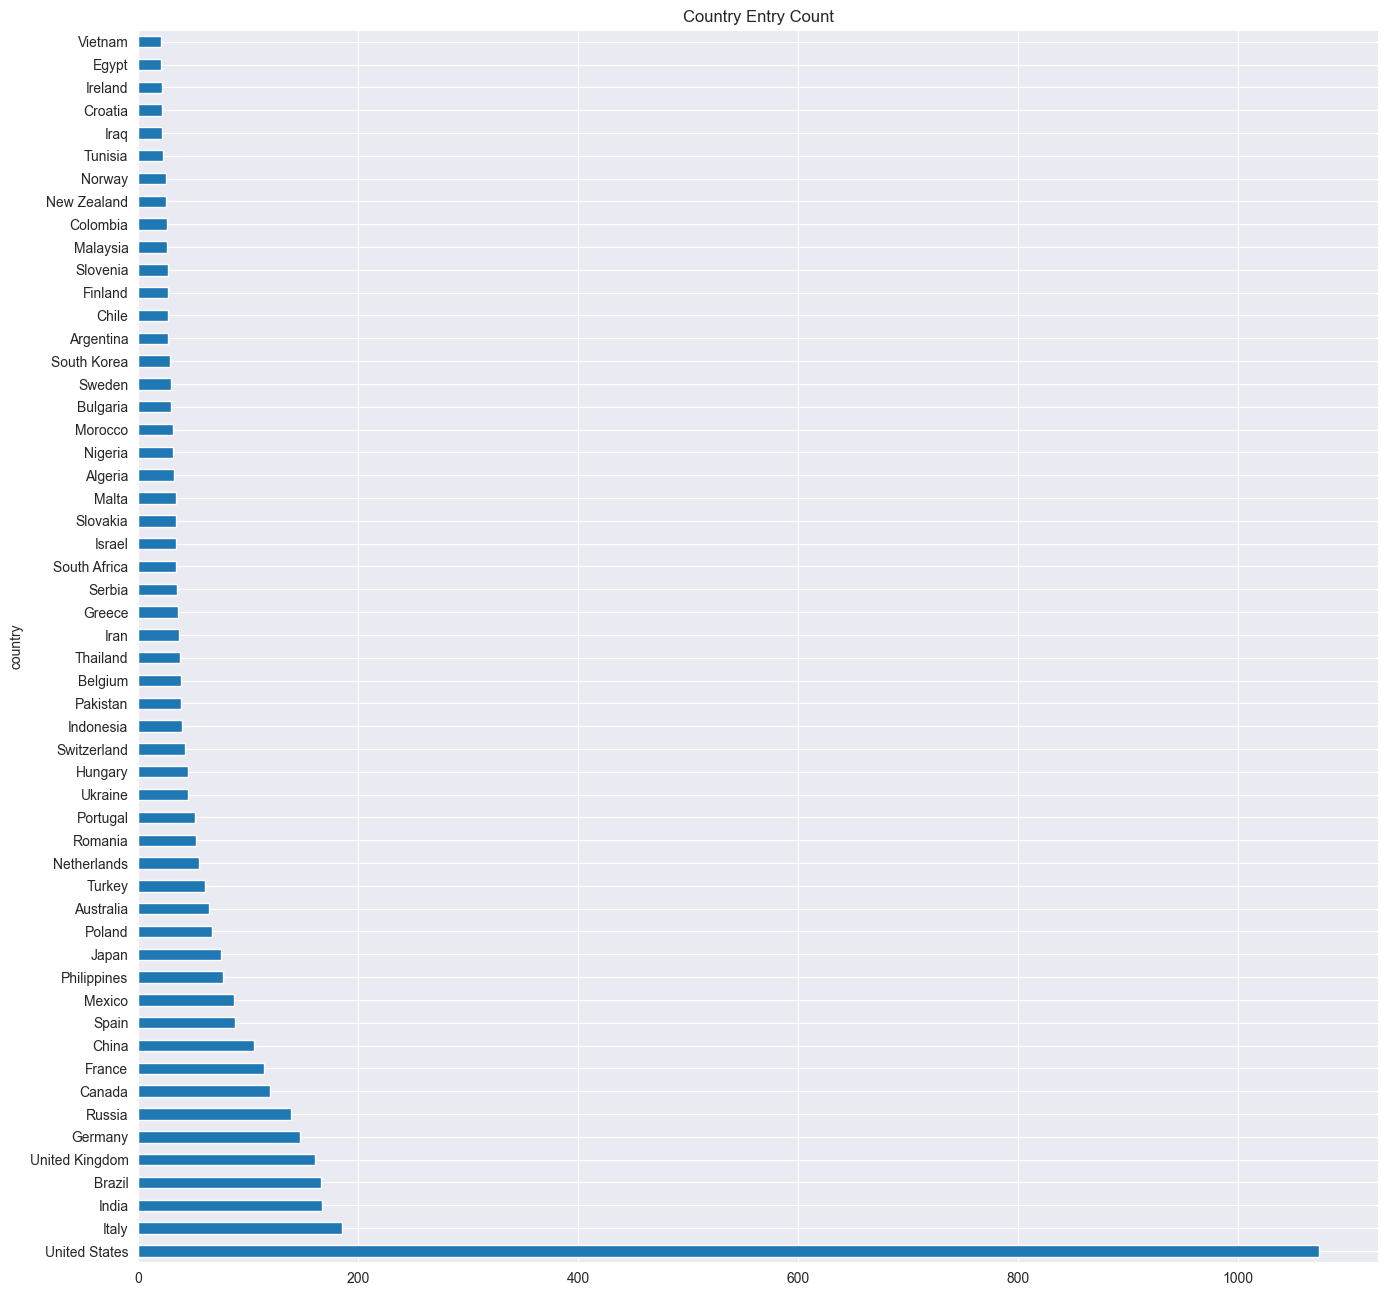

In [205]:
country_counts = grocery_df['country'].value_counts()
plt.figure(figsize=(16,16))
country_counts.plot(kind='barh', title='Country Entry Count')

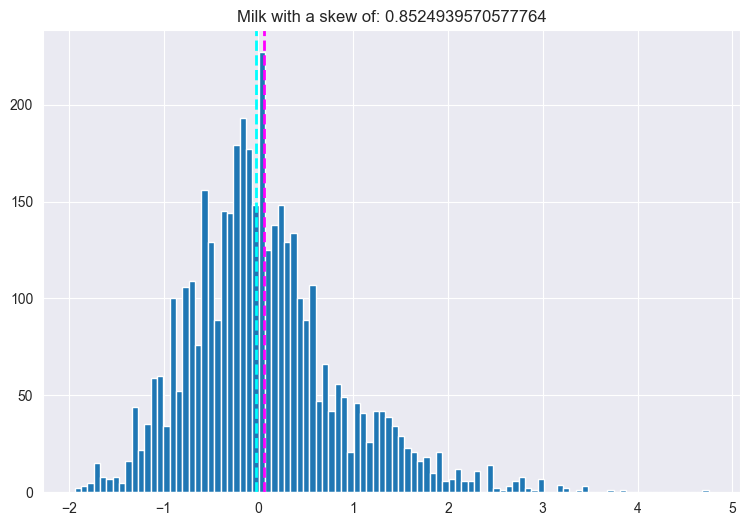

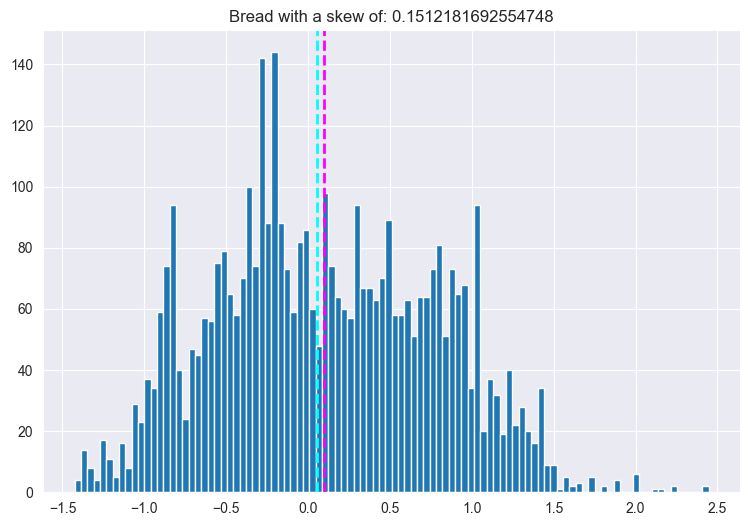

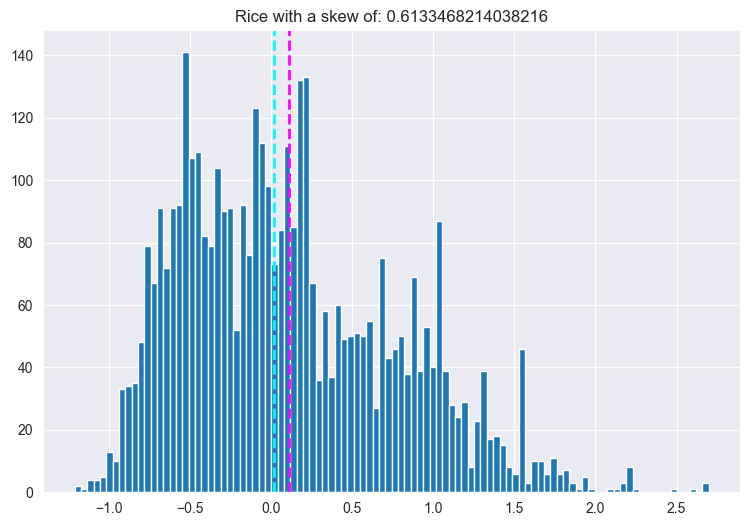

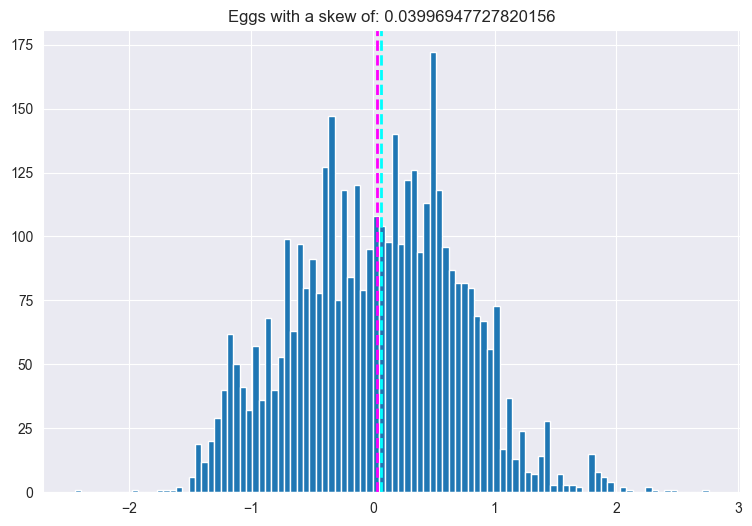

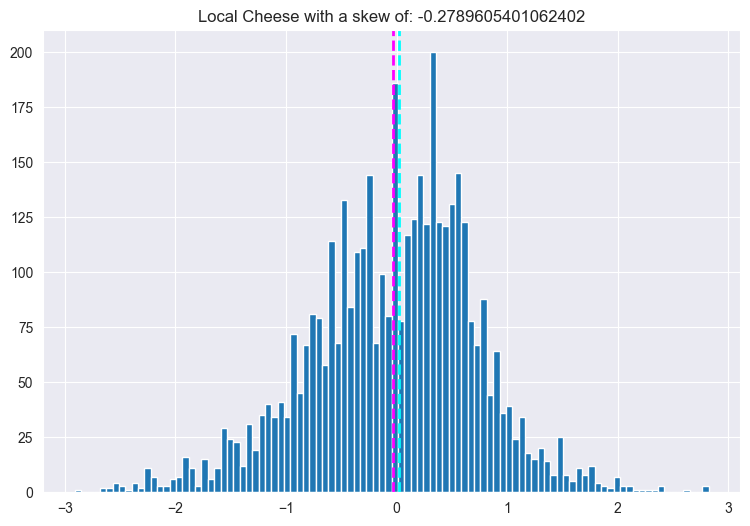

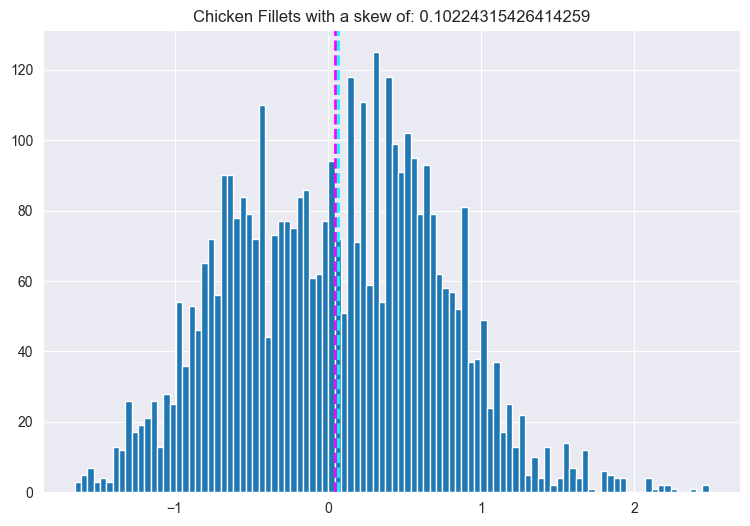

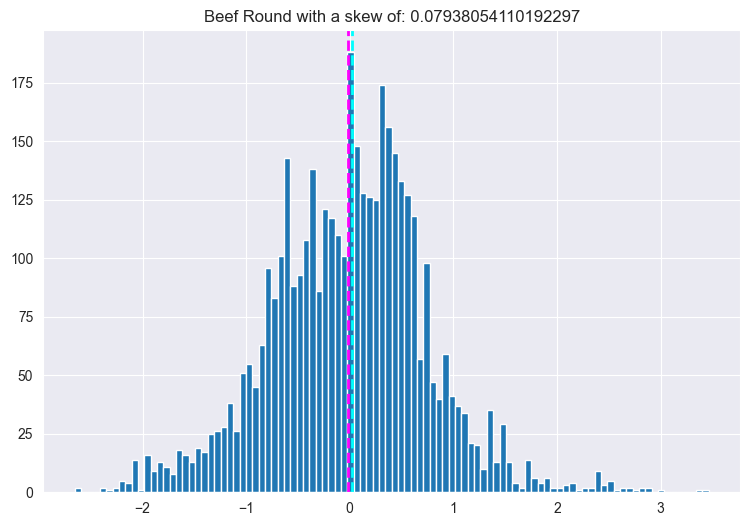

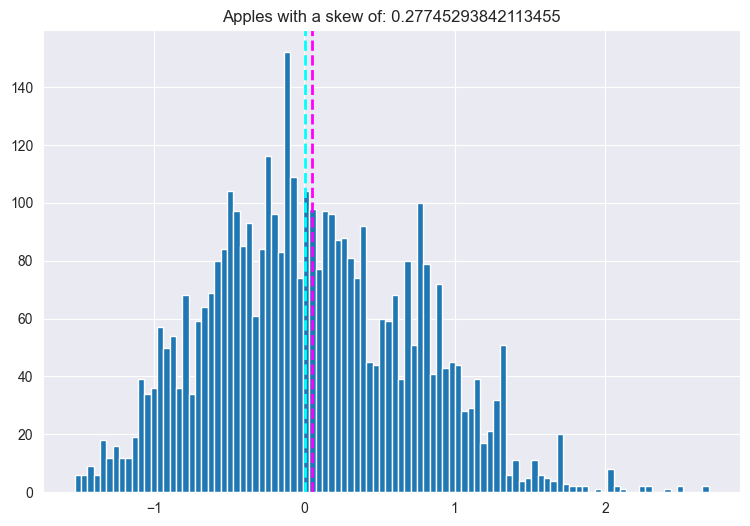

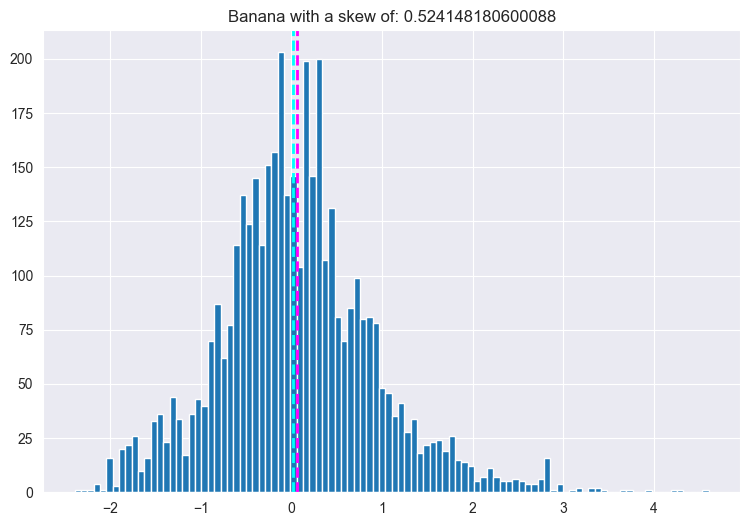

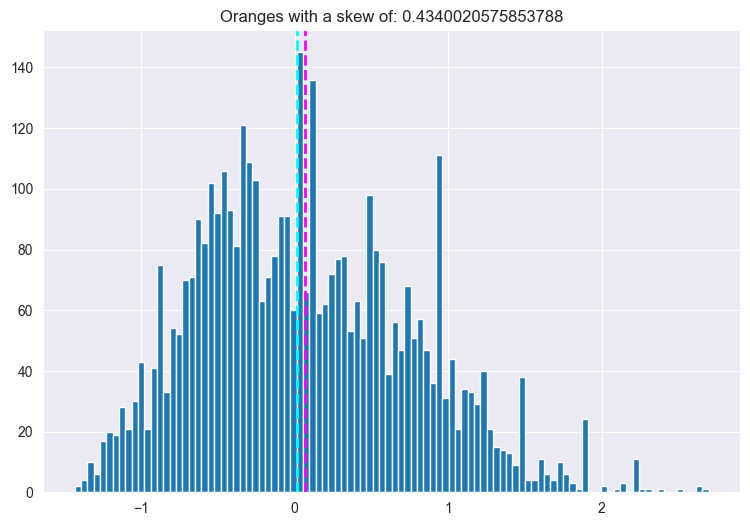

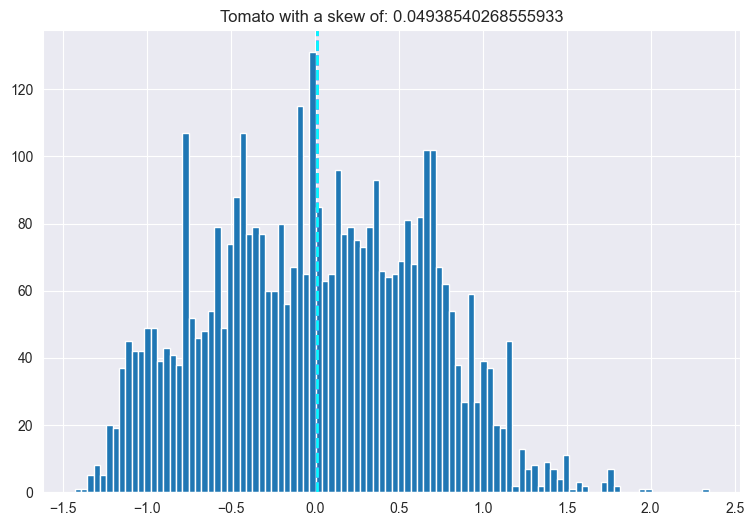

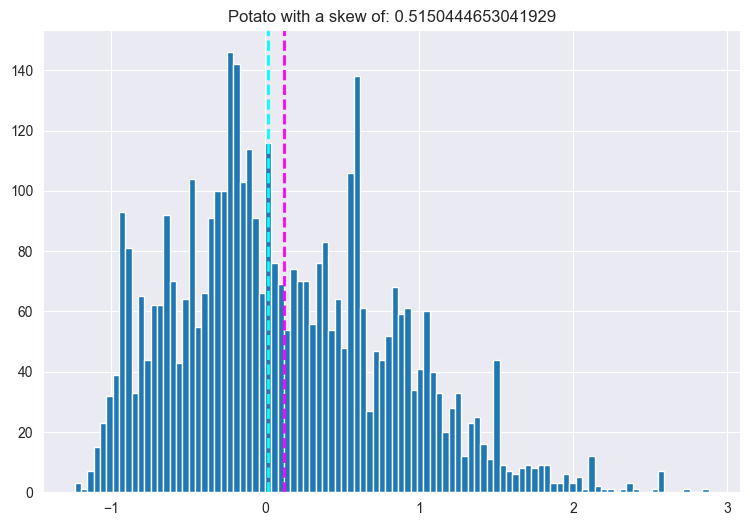

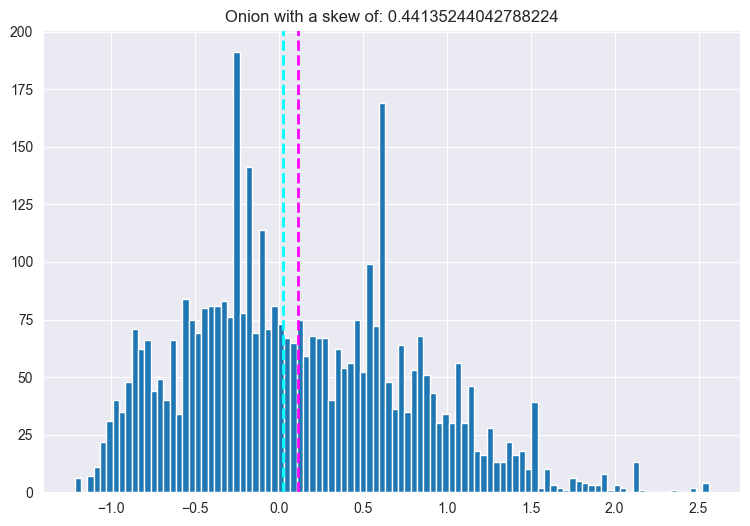

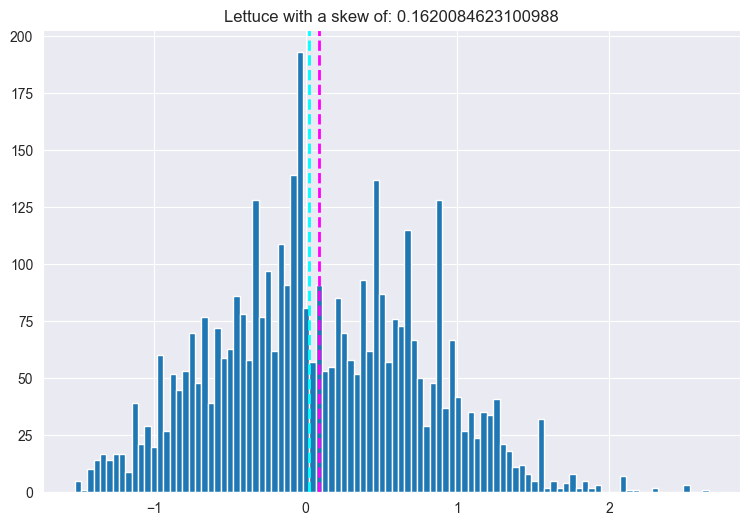

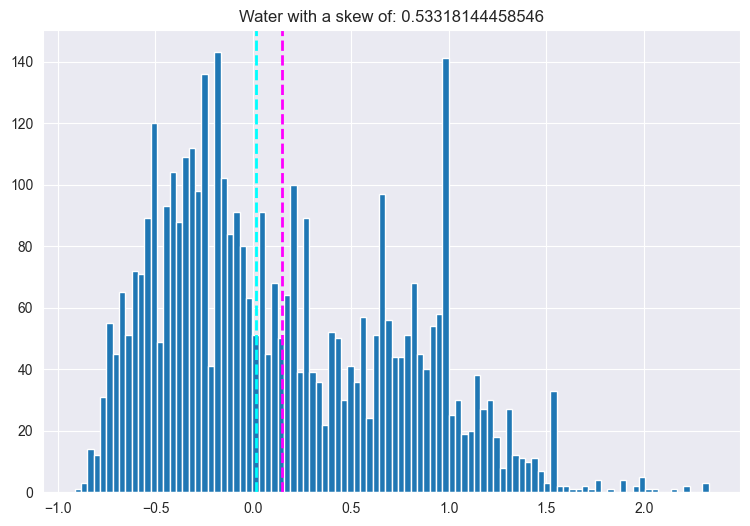

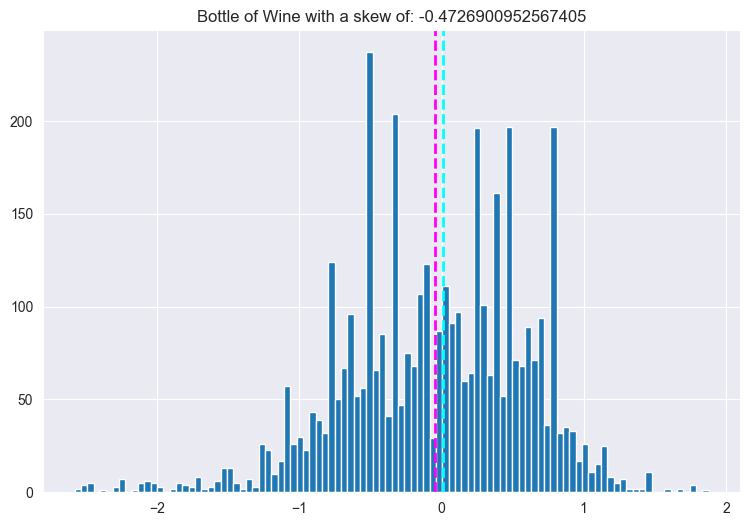

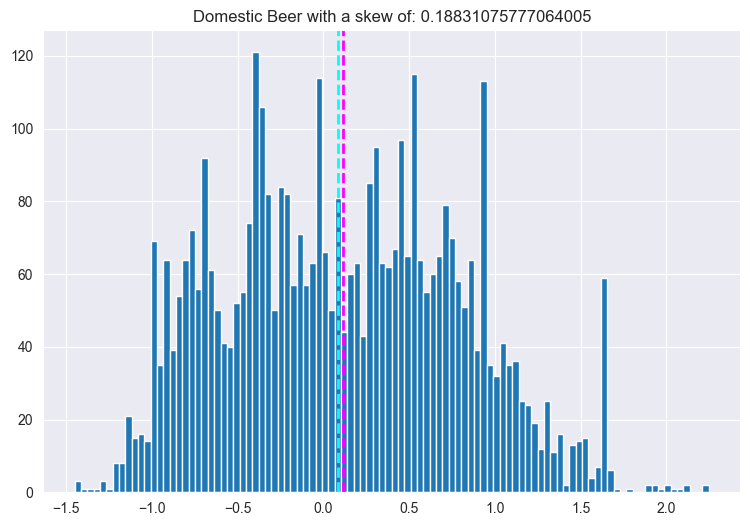

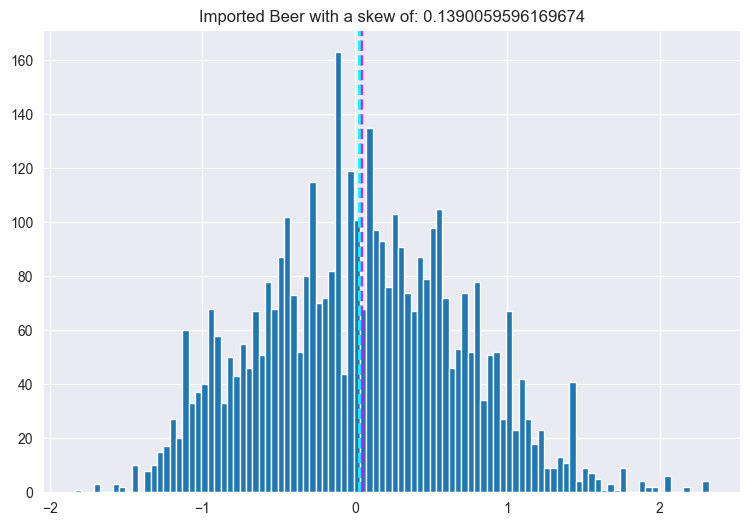

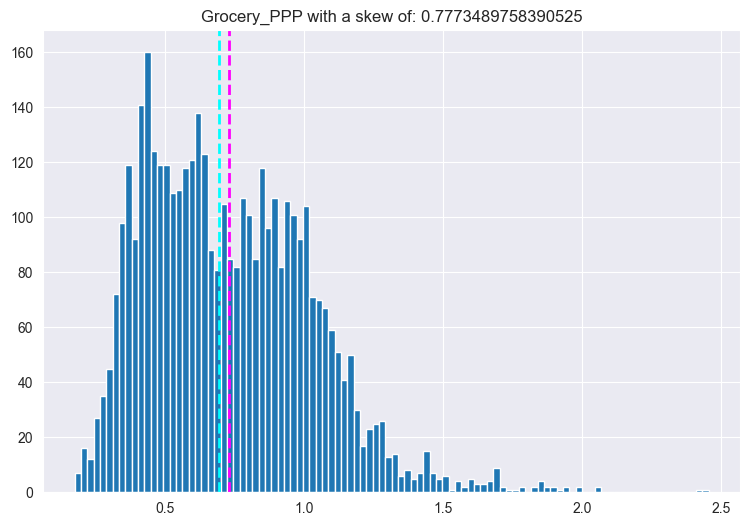

In [222]:
def plot_histogram(df, col):
    fig = plt.figure(figsize=(9, 6))
    ax = fig.gca()
    feature = df[col]#Complete this part#
    feature.hist(bins=100, ax = ax)
    ax.axvline(feature.mean(), color='magenta', linestyle='dashed', linewidth=2)
    ax.axvline(feature.median(), color='cyan', linestyle='dashed', linewidth=2)
    skew = df[col].skew()
    ax.set_title(f"{col} with a skew of: {skew}")

for col in feature_names:
    plot_histogram(grocery_df_imputed, col)
plt.show()

In [223]:
skew_values = grocery_df_imputed[feature_names].skew()
print(skew_values.sort_values(ascending=False))

Milk               0.852494
Grocery_PPP        0.777349
Rice               0.613347
Water              0.533181
Banana             0.524148
Potato             0.515044
Onion              0.441352
Oranges            0.434002
Apples             0.277453
Domestic Beer      0.188311
Lettuce            0.162008
Bread              0.151218
Imported Beer      0.139006
Chicken Fillets    0.102243
Beef Round         0.079381
Tomato             0.049385
Eggs               0.039969
Local Cheese      -0.278961
Bottle of Wine    -0.472690
dtype: float64


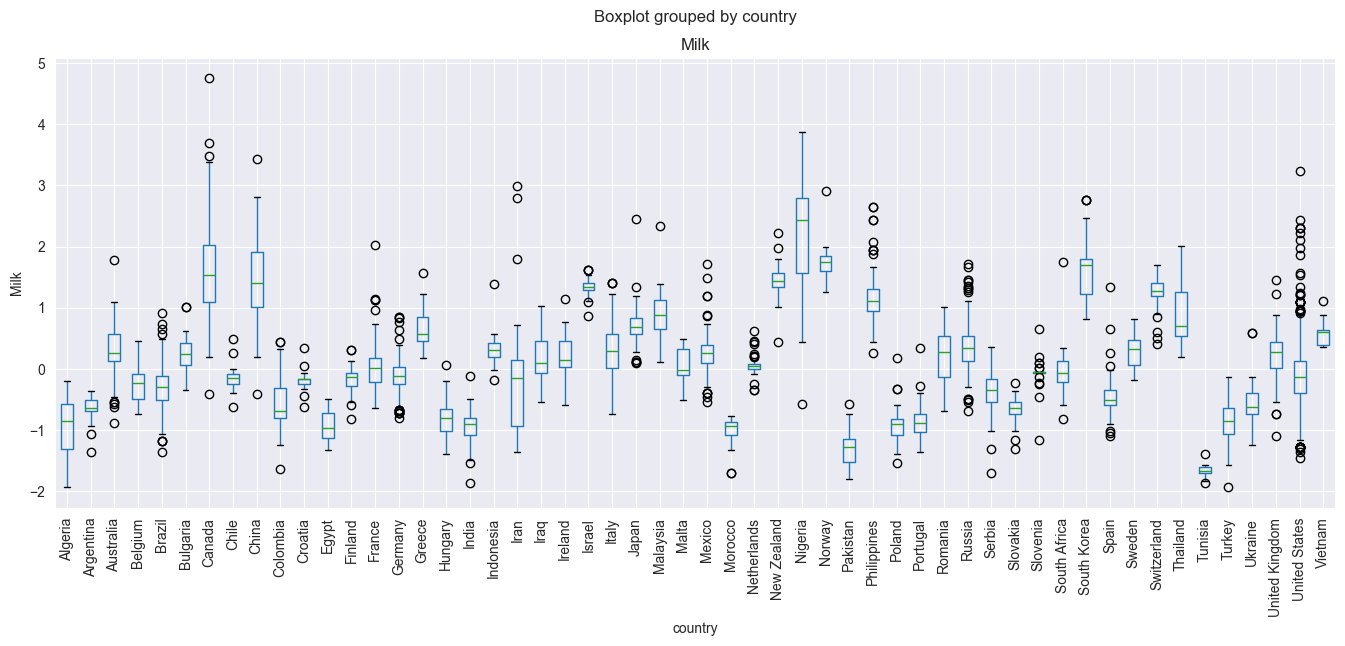

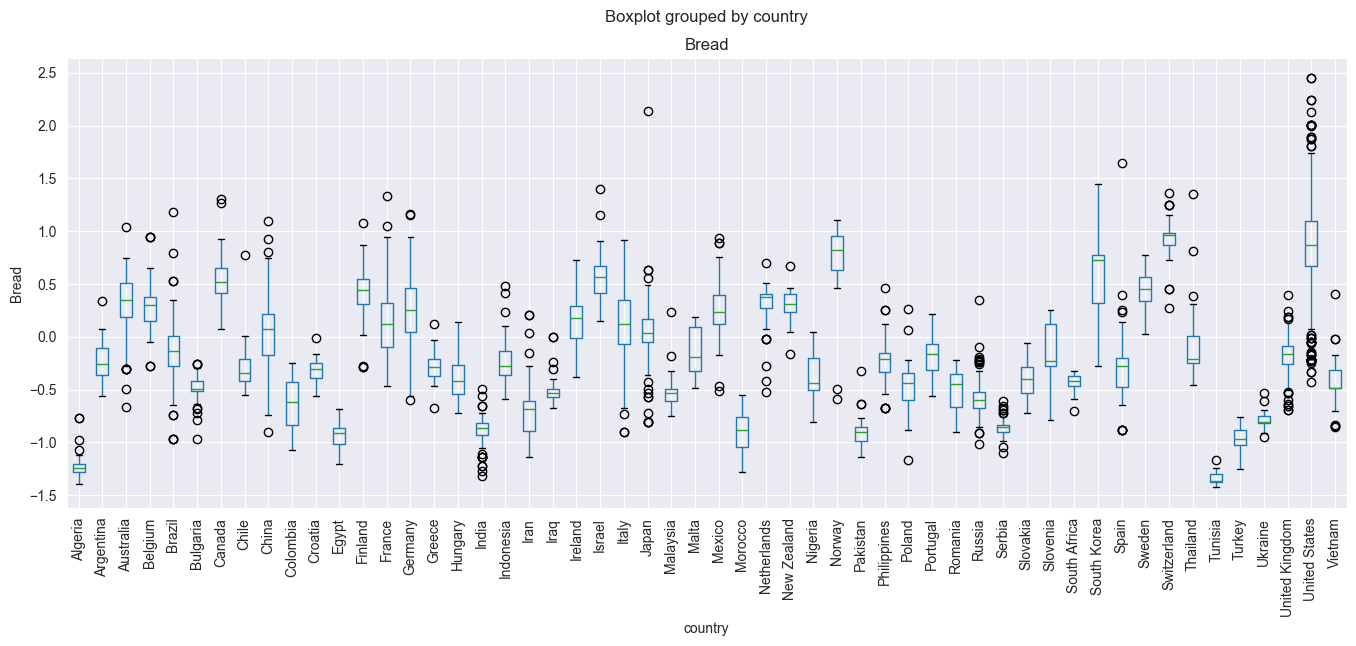

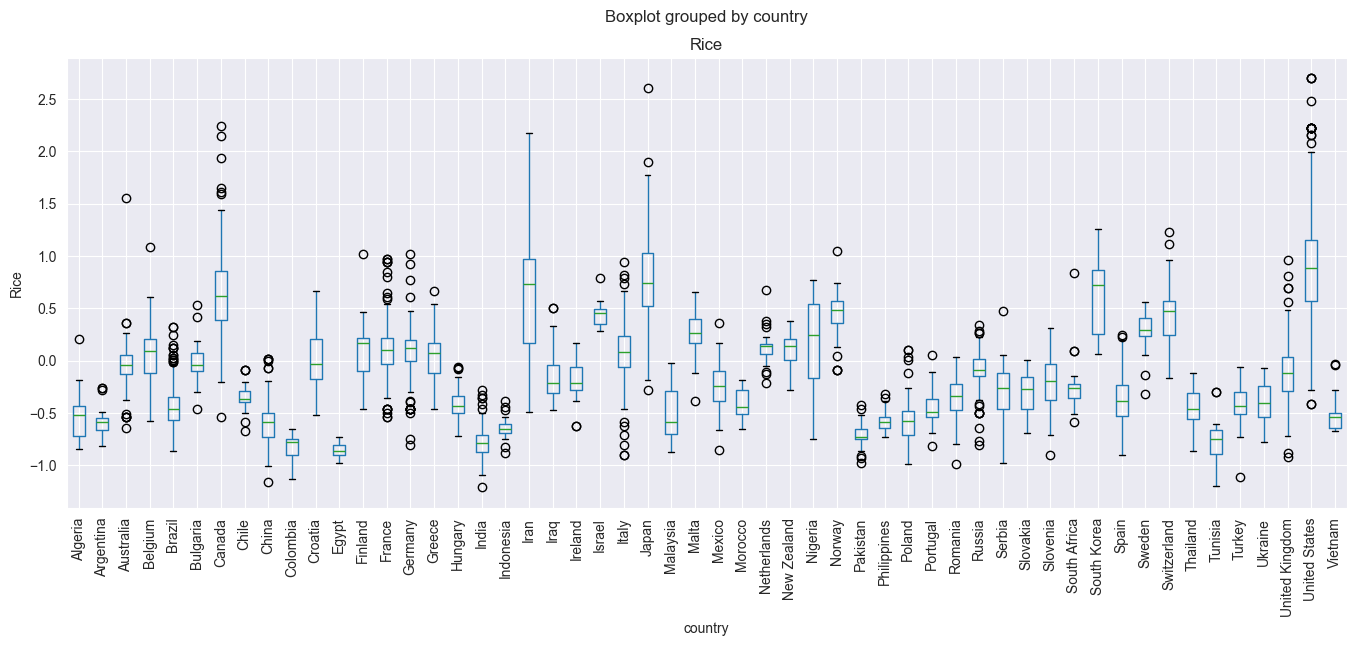

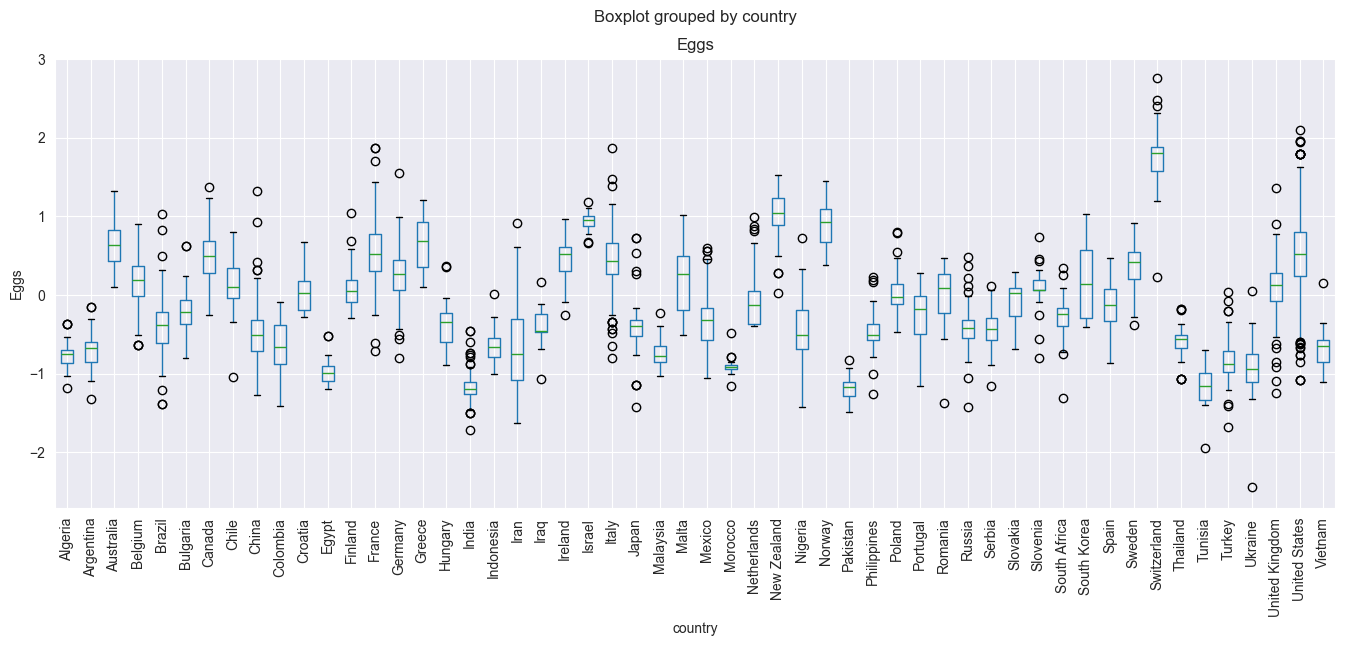

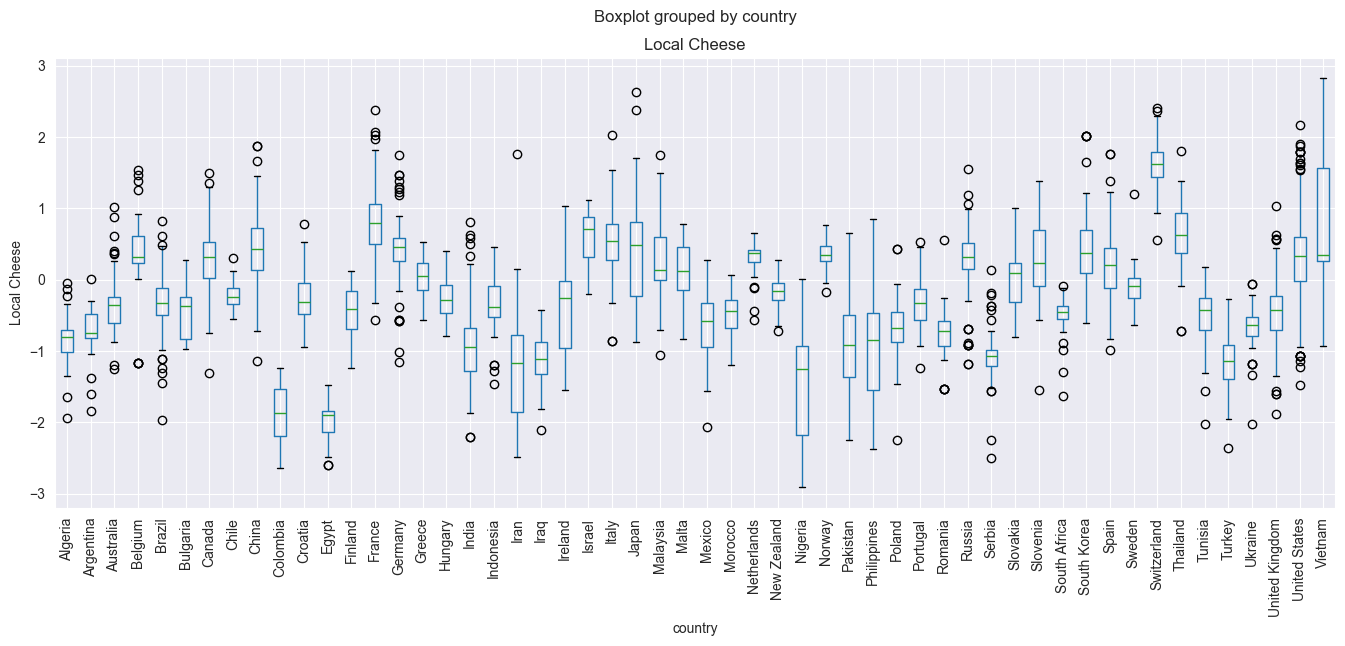

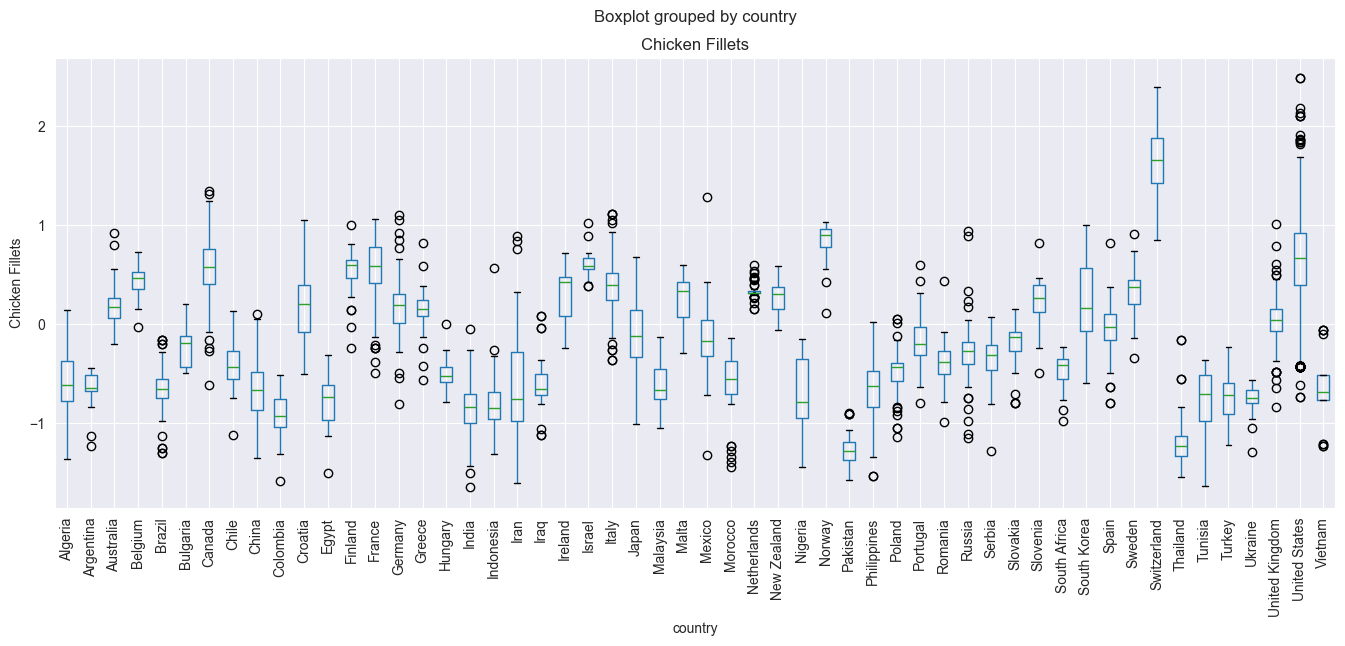

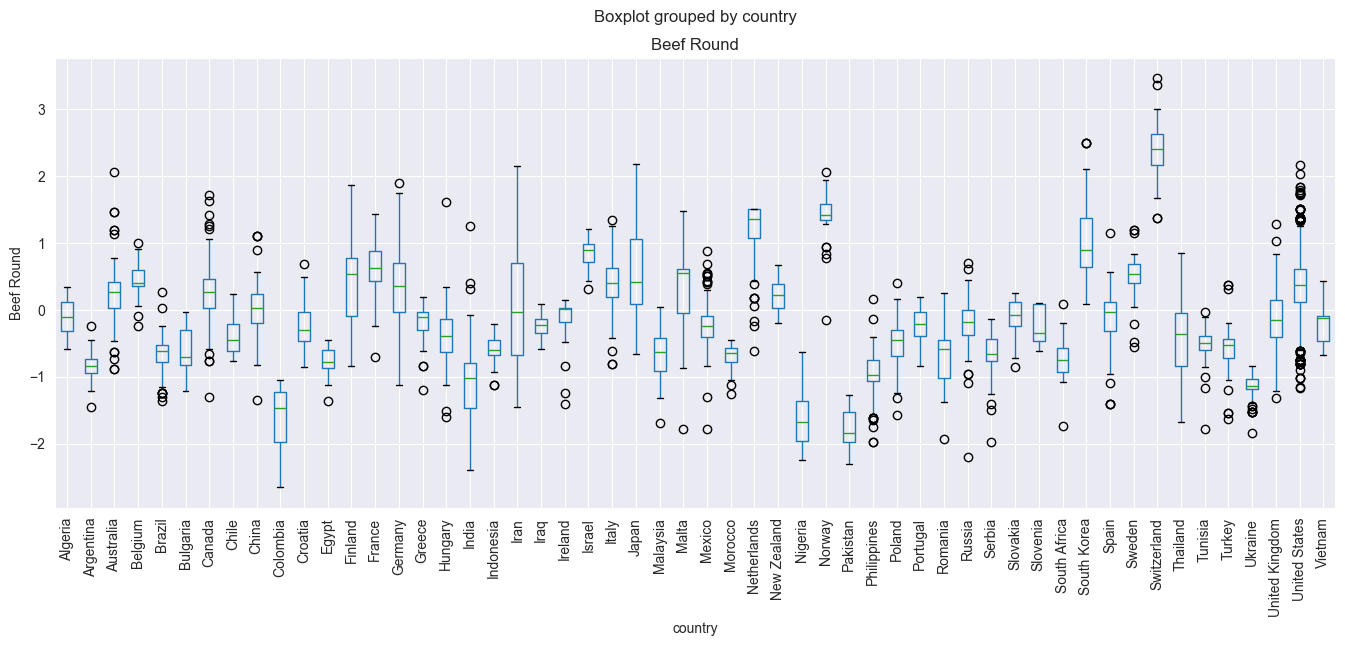

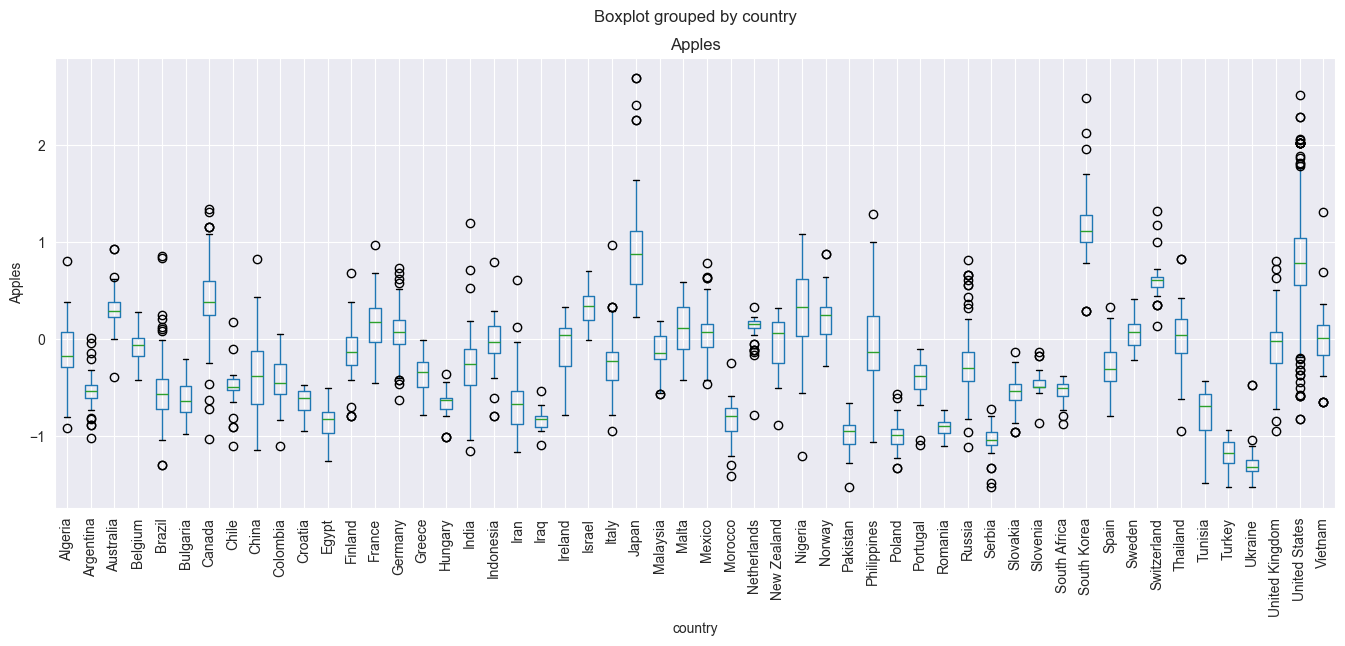

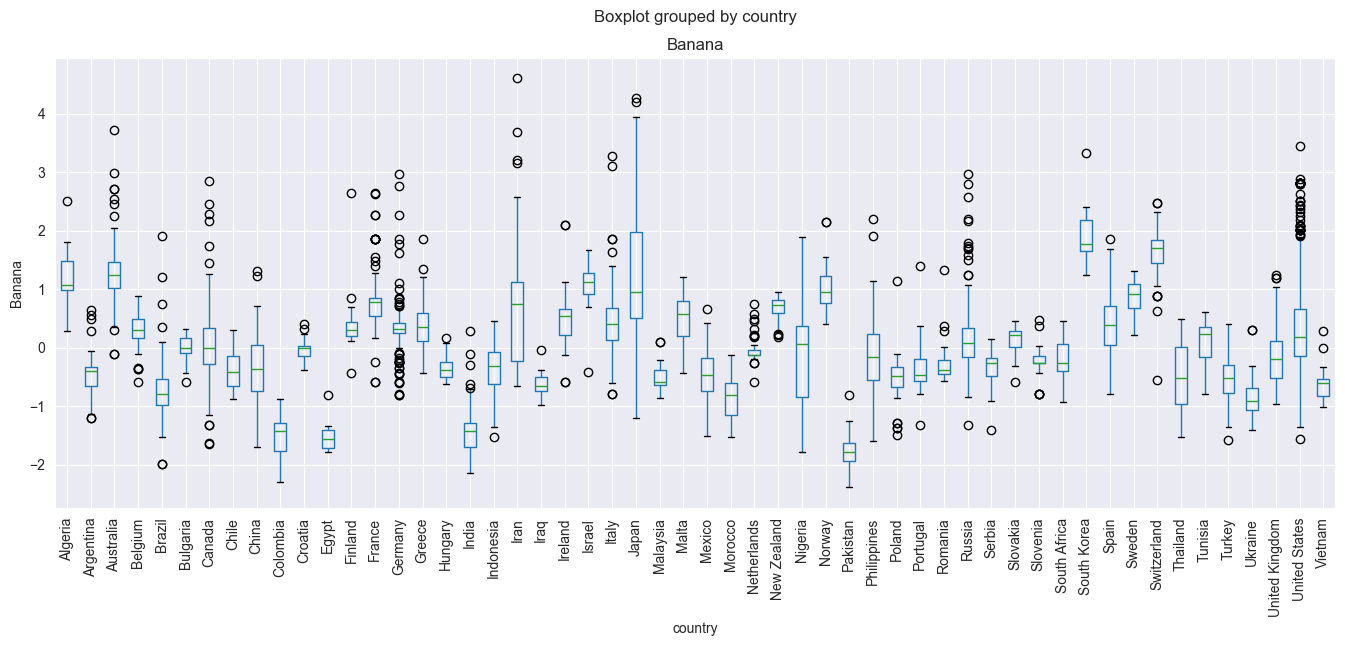

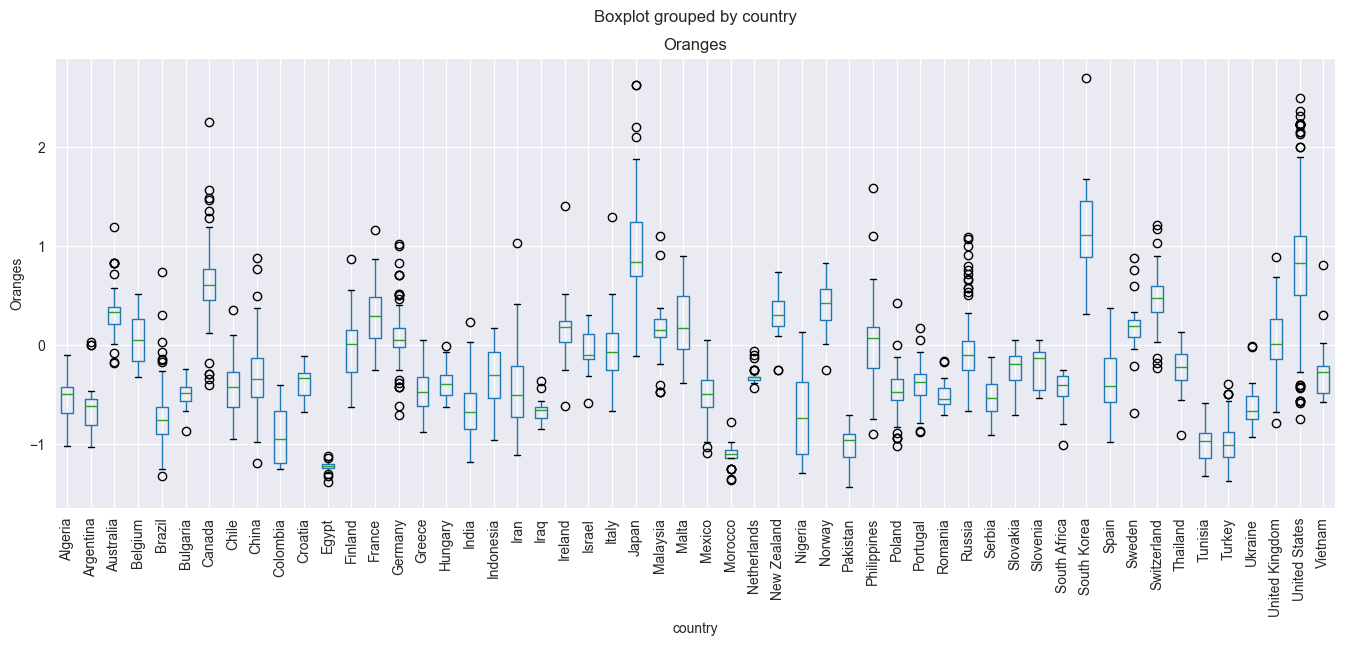

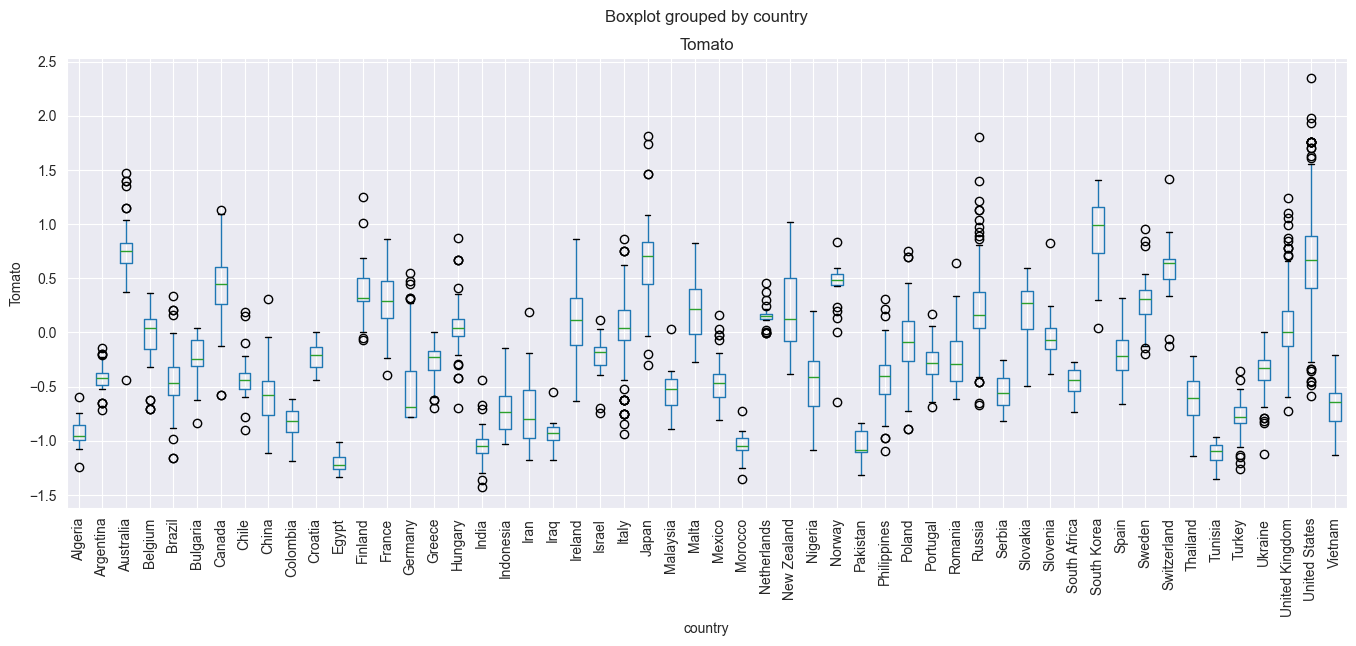

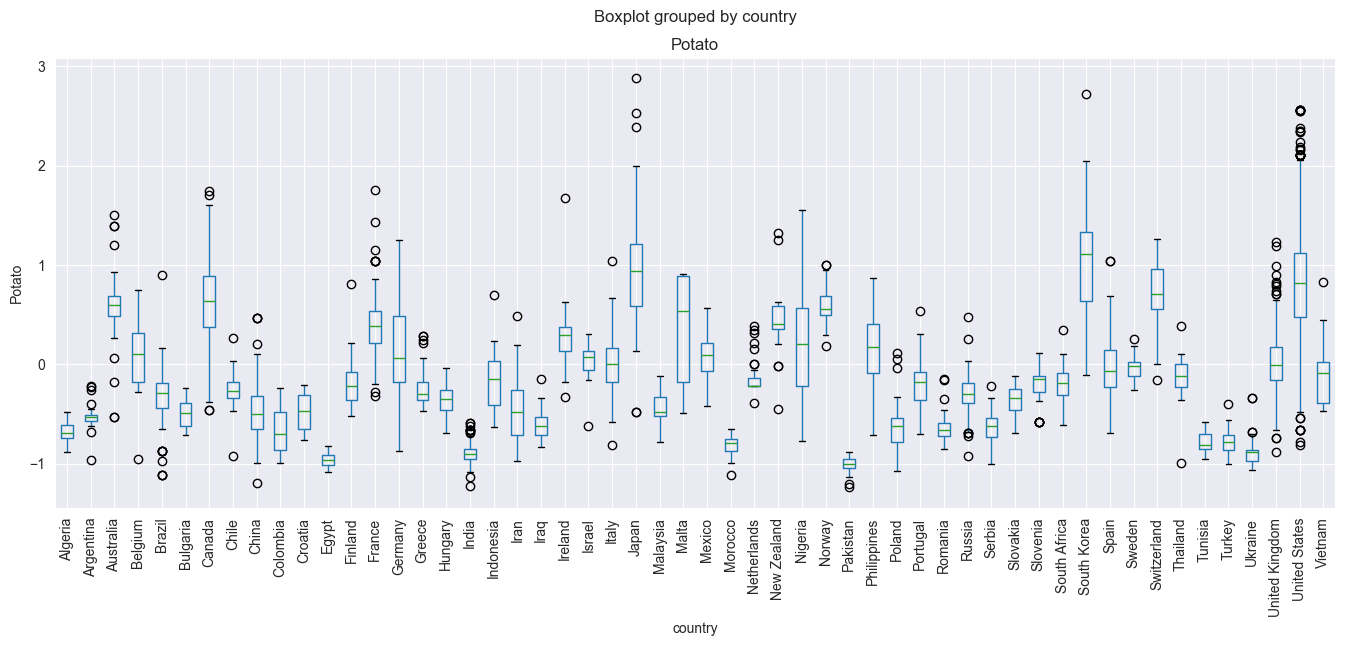

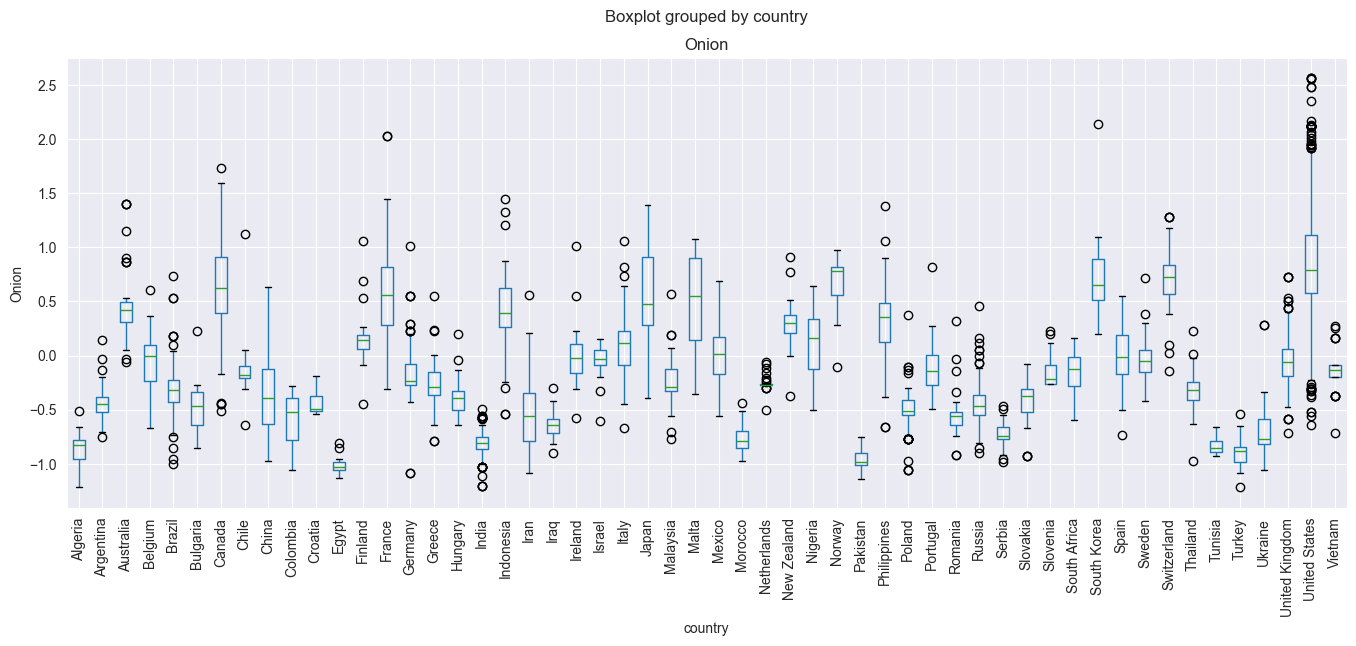

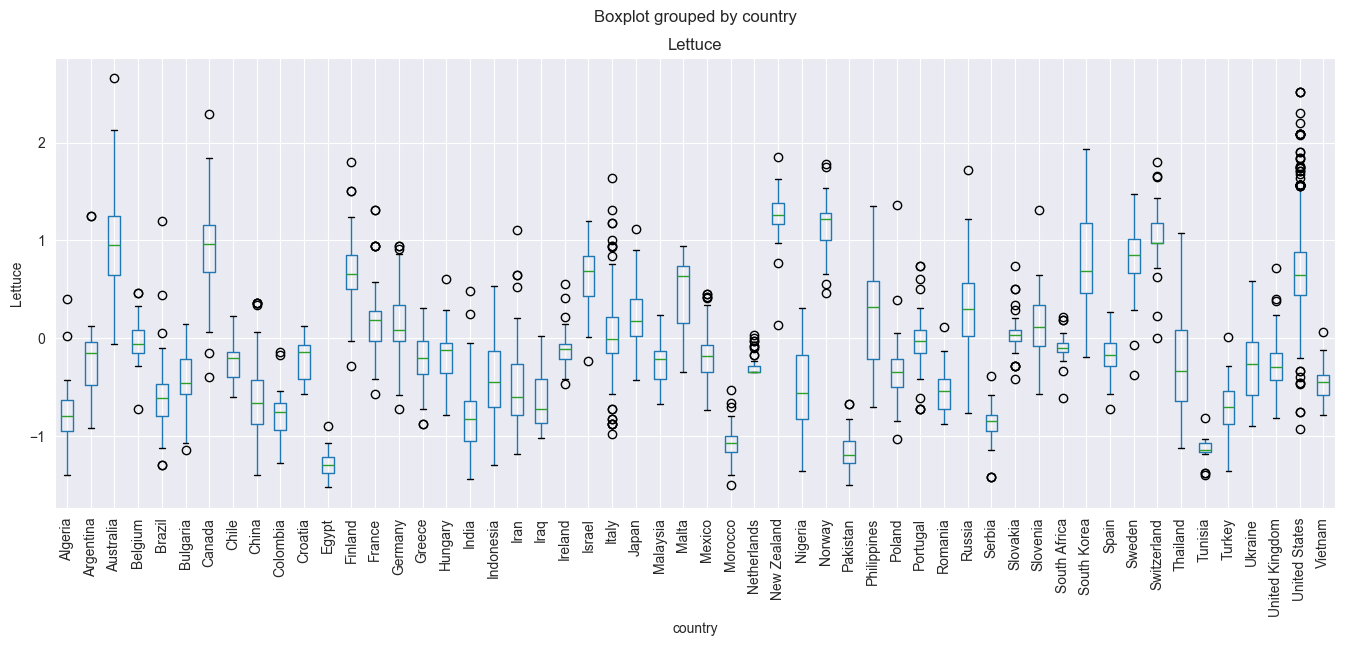

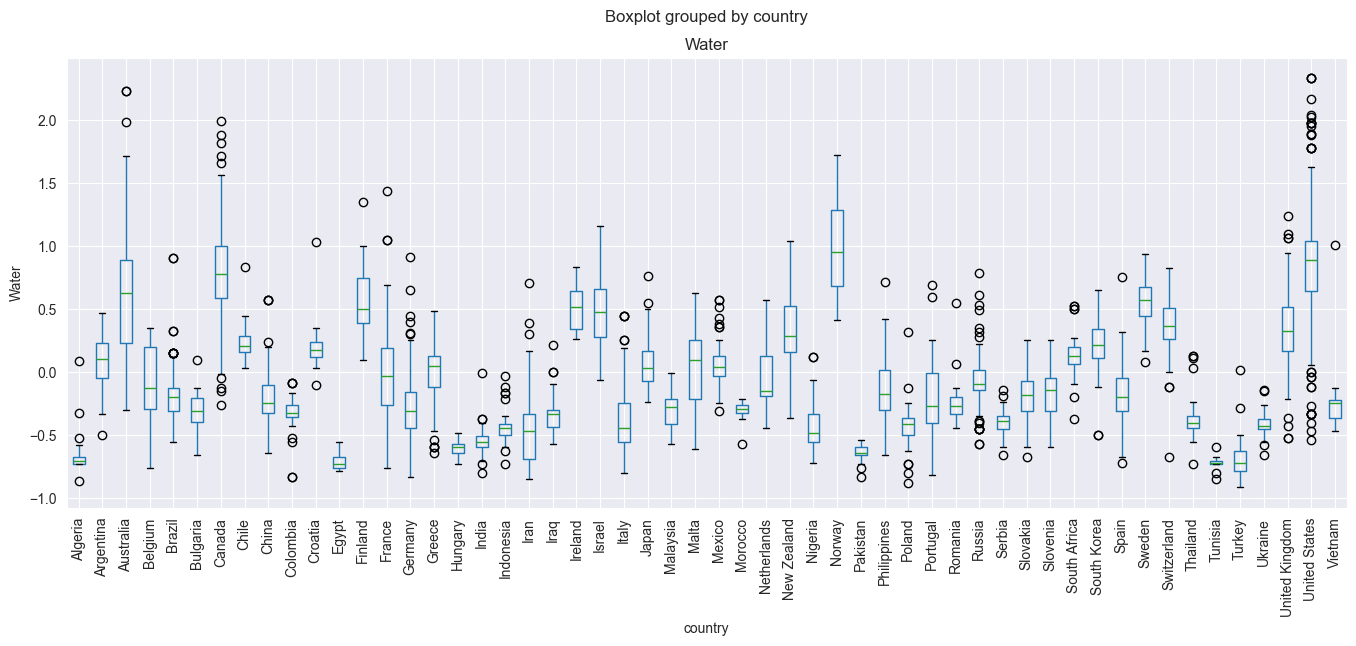

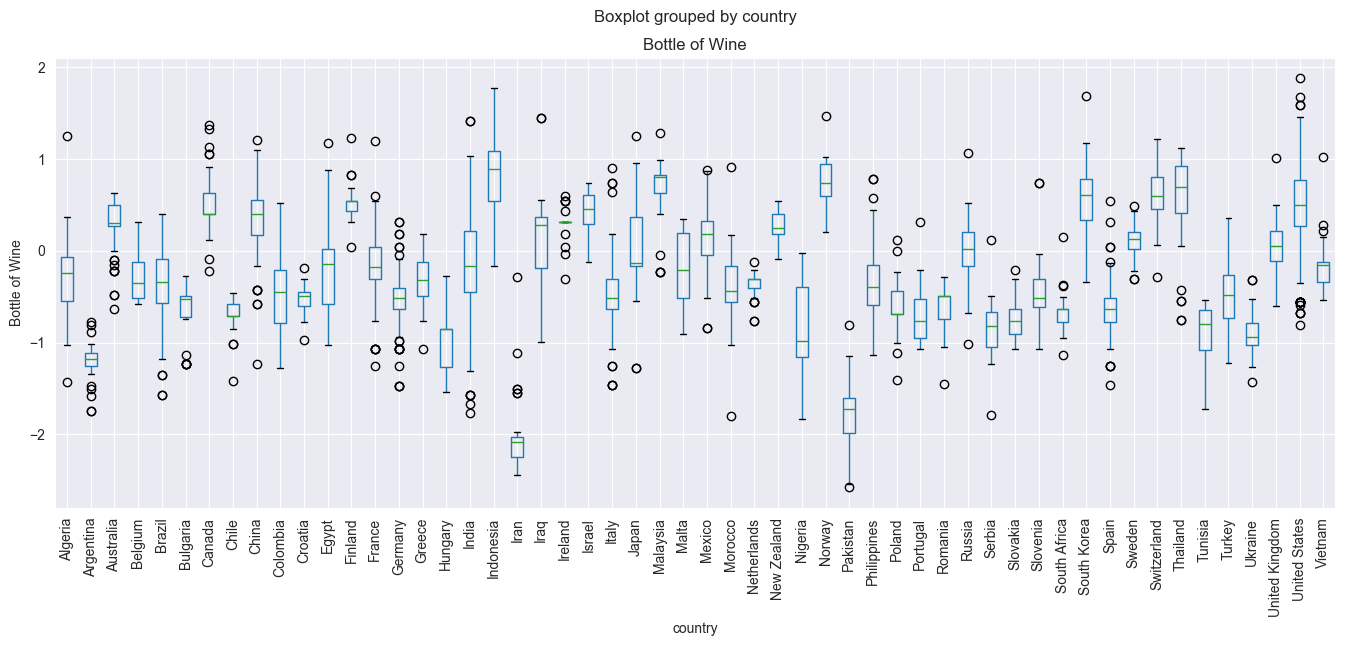

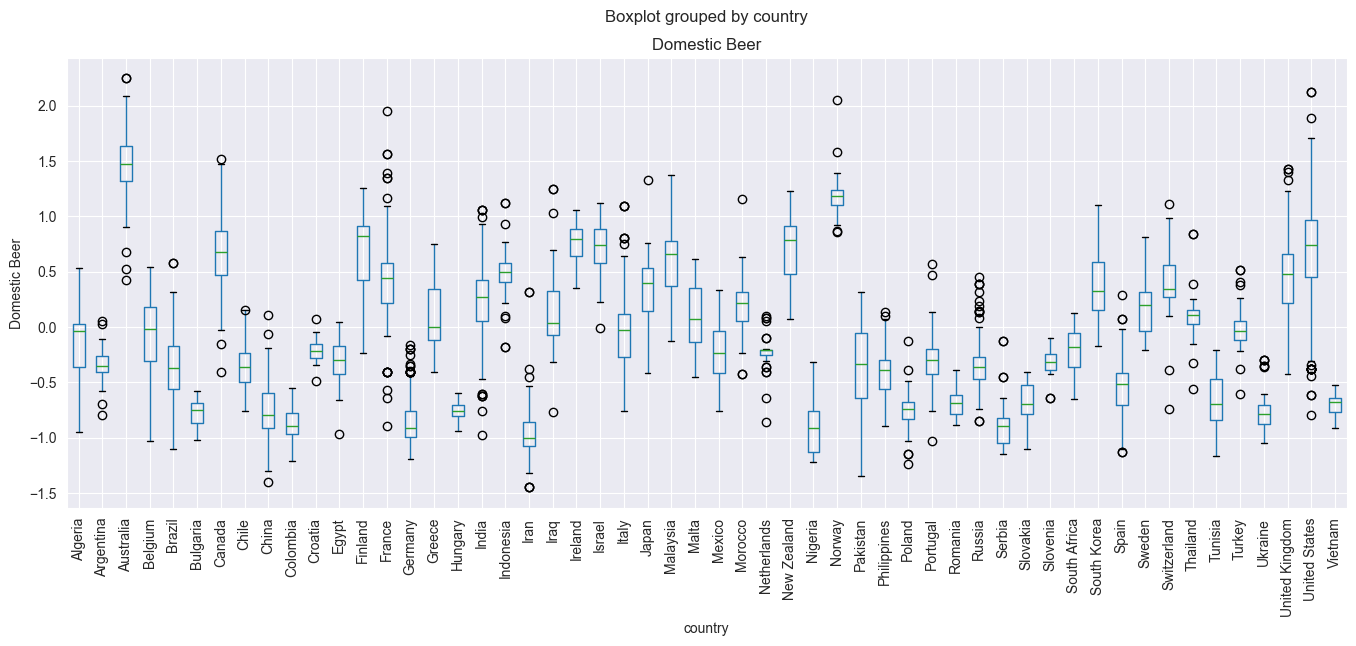

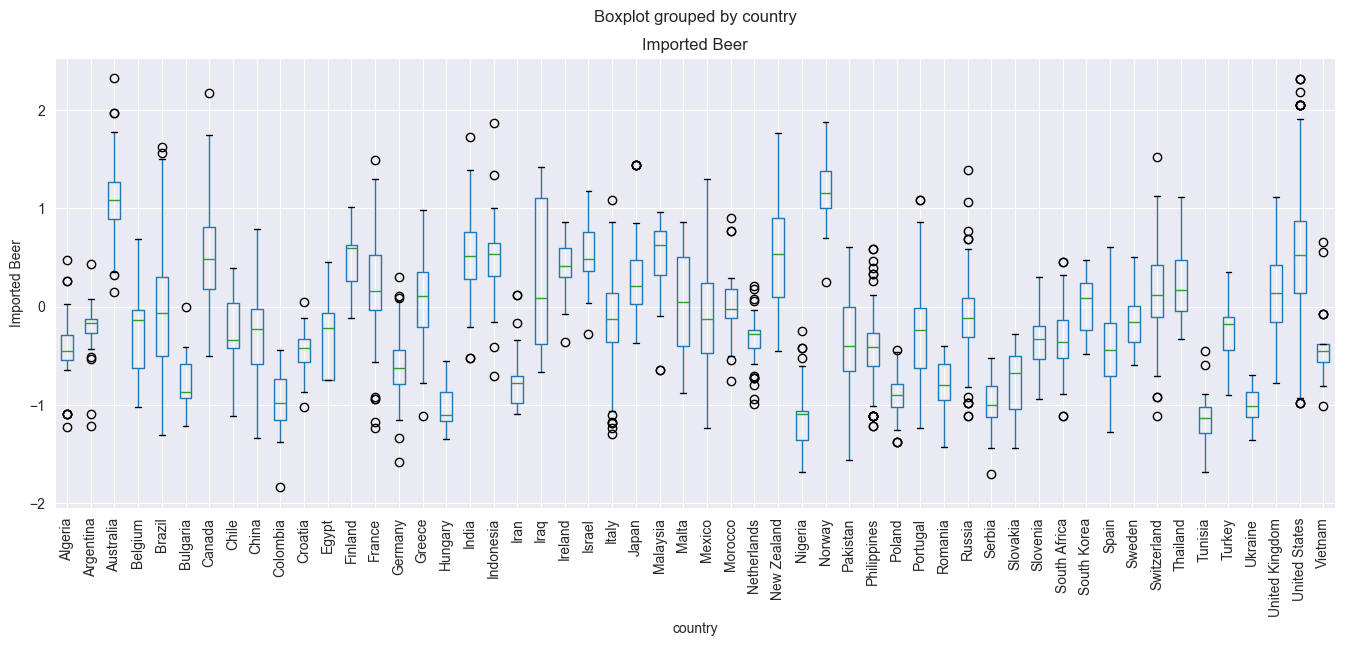

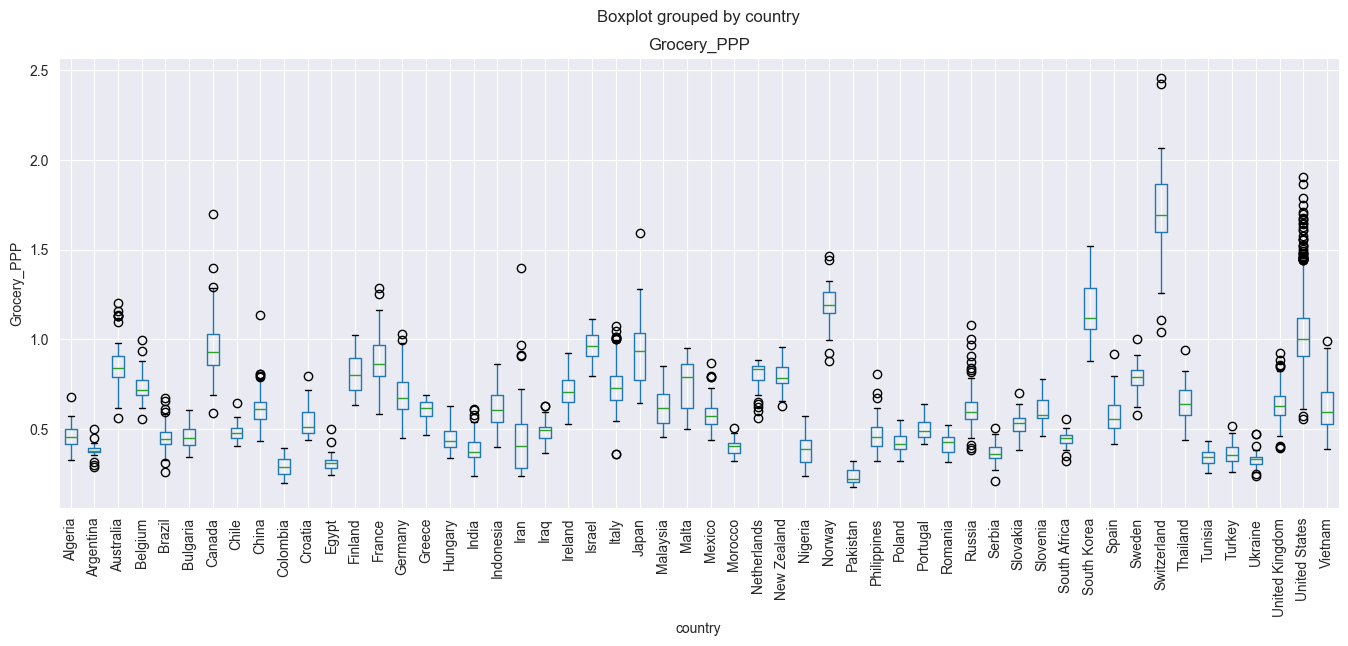

In [224]:
def plot_boxplot(df, col):
    fig = plt.figure(figsize=(16,6))
    ax = fig.gca()
    df.boxplot(column=col, by='country',ax=ax, rot=90)
    ax.set_ylabel(col)
    plt.title(col)

for col in feature_names:
    plot_boxplot(grocery_df_imputed, col)


# #Transform


In [209]:
np.random.seed(3)
grocery_df[feature_names] = np.log1p(grocery_df[feature_names])

# #Scaling


In [210]:
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()
grocery_df[feature_names] = robust_scaler.fit_transform(grocery_df[feature_names])

# #Imputation


In [211]:
def knn_impute(df, group_col, target_cols, k):
    imputed_frames = []

    for name, group in df.groupby(group_col):
        group_impute = group.copy()
        n_samples = group_impute.shape[0]
        group_k = min(k, n_samples - 1)

        if group_k >= 1:
            knn_imputer = KNNImputer(n_neighbors=group_k)
            group_impute[target_cols] = knn_imputer.fit_transform(group_impute[target_cols])
        imputed_frames.append(group_impute)
    return pd.concat(imputed_frames).sort_index()

numeric_cols = grocery_df.select_dtypes(include=[np.number]).columns.tolist()
cols_to_exclude = ['Unnamed: 0', 'data_quality']
price_columns = [col for col in numeric_cols if col not in cols_to_exclude]
grocery_df_imputed = knn_impute(grocery_df, 'country', price_columns, k=5)
grocery_df_imputed.isnull().any()



city               False
country            False
Milk               False
Bread              False
Rice               False
Eggs               False
Local Cheese       False
Chicken Fillets    False
Beef Round         False
Apples             False
Banana             False
Oranges            False
Tomato             False
Potato             False
Onion              False
Lettuce            False
Water              False
Bottle of Wine     False
Domestic Beer      False
Imported Beer      False
dtype: bool

In [212]:
grocery_df_imputed.head()

,city,country,Milk,Bread,Rice,Eggs,Local Cheese,Chicken Fillets,Beef Round,Apples,Banana,Oranges,Tomato,Potato,Onion,Lettuce,Water,Bottle of Wine,Domestic Beer,Imported Beer
0,Delhi,India,-0.720212,-0.795766,-0.580801,-1.066546,-1.100025,-0.595742,-0.999684,-0.278530,-1.131433,-0.633683,-0.951643,-0.883784,-0.802065,-0.452543,-0.522700,0.239237,0.051066,0.250496
1,Shanghai,China,2.679168,0.695405,-0.356846,-0.021604,1.141036,-0.364013,0.234152,-0.057790,0.182640,0.065737,-0.368539,-0.376790,-0.179129,-0.291841,-0.186430,0.684677,-0.547049,-0.144353
2,Jakarta,Indonesia,0.523062,-0.135695,-0.621576,-0.389675,-0.458519,-0.693818,-0.417823,0.203791,0.141333,0.050205,-0.499797,0.067953,0.563015,0.078729,-0.439715,1.187242,0.455734,0.632406
3,Manila,Philippines,1.166233,-0.151450,-0.572776,-0.364331,-0.870838,-0.485547,-0.748594,0.144503,0.000000,0.448855,-0.396002,0.347795,0.355430,0.320317,-0.151159,0.113855,-0.295211,-0.448029
4,Seoul,South Korea,1.950104,0.794461,0.792310,1.032746,0.350397,0.621851,2.063993,1.337551,2.316939,1.454772,1.097688,1.332381,0.920354,1.180540,0.275433,0.781985,0.483366,0.238004


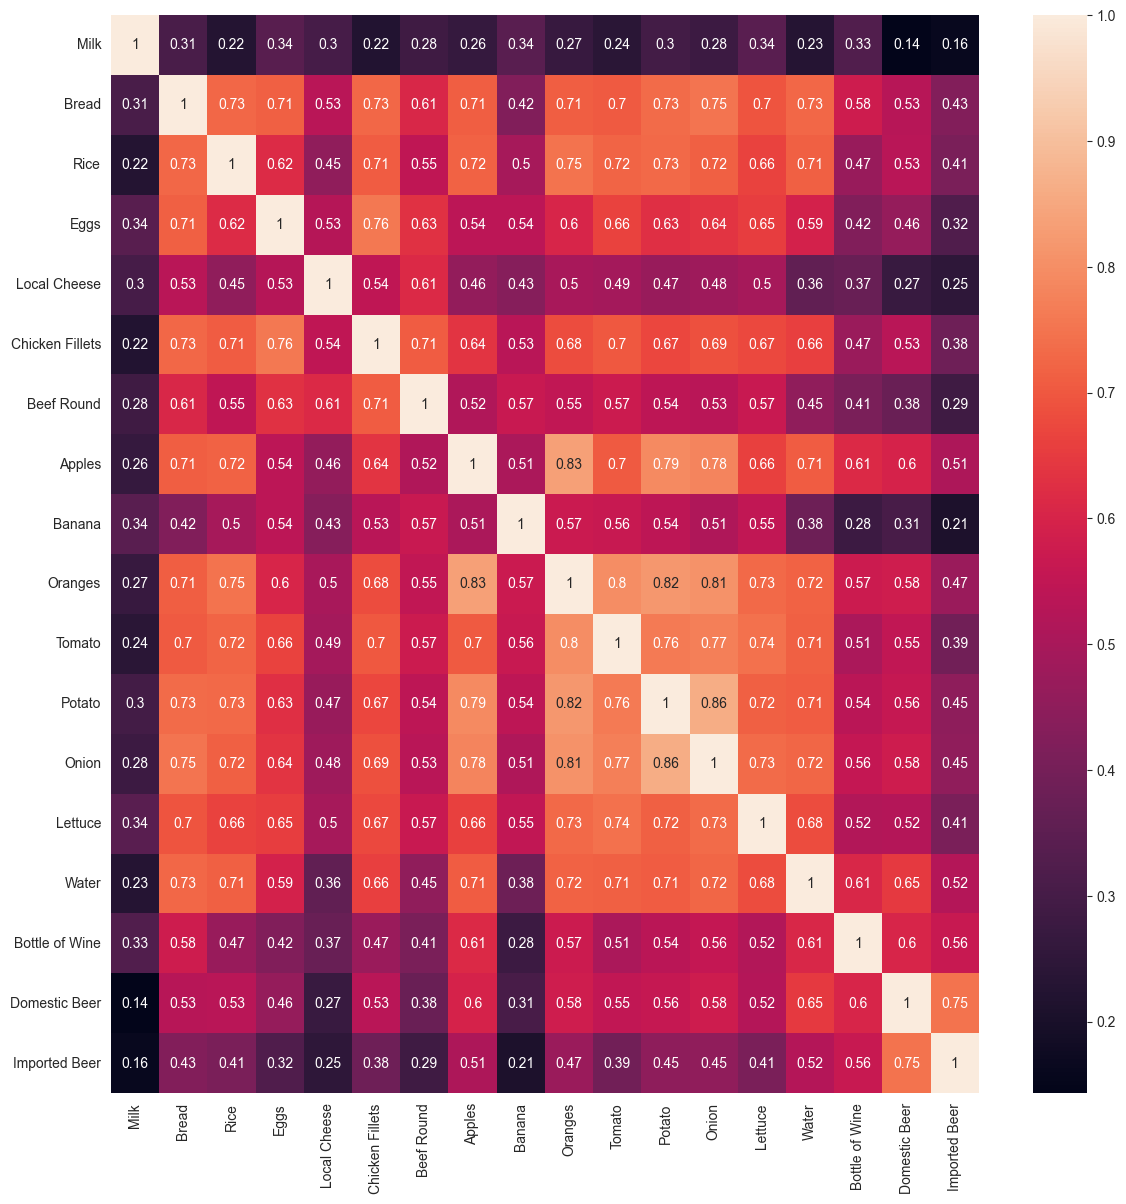

In [213]:
plt.figure(figsize=(14,14))
sns.heatmap(grocery_df_imputed[feature_names].corr(), annot=True)
plt.show()

In [214]:
grocery_df_imputed[feature_names].corr()

,Milk,Bread,Rice,Eggs,Local Cheese,Chicken Fillets,Beef Round,Apples,Banana,Oranges,Tomato,Potato,Onion,Lettuce,Water,Bottle of Wine,Domestic Beer,Imported Beer
Milk,1.000000,0.309513,0.224189,0.339796,0.303271,0.220932,0.284561,0.264931,0.341169,0.269753,0.240038,0.296709,0.278109,0.341360,0.228263,0.326068,0.143150,0.160947
Bread,0.309513,1.000000,0.726282,0.712260,0.532772,0.727422,0.605565,0.711061,0.423825,0.711426,0.702192,0.734081,0.750721,0.695379,0.727165,0.577516,0.531034,0.426697
Rice,0.224189,0.726282,1.000000,0.615811,0.452150,0.706023,0.545828,0.715781,0.495611,0.746127,0.720752,0.731120,0.715499,0.663708,0.713729,0.469649,0.534540,0.410637
Eggs,0.339796,0.712260,0.615811,1.000000,0.525655,0.758795,0.630624,0.540310,0.540413,0.603520,0.664825,0.626793,0.635745,0.653046,0.594985,0.421490,0.464004,0.323148
Local Cheese,0.303271,0.532772,0.452150,0.525655,1.000000,0.544817,0.613557,0.459484,0.431739,0.499859,0.493787,0.468253,0.479597,0.497858,0.359957,0.373494,0.271590,0.250101
Chicken Fillets,0.220932,0.727422,0.706023,0.758795,0.544817,1.000000,0.708545,0.635609,0.531648,0.680292,0.701944,0.669549,0.685655,0.673305,0.658229,0.472932,0.533248,0.384488
Beef Round,0.284561,0.605565,0.545828,0.630624,0.613557,0.708545,1.000000,0.516783,0.566629,0.548320,0.574850,0.542118,0.532242,0.566716,0.454307,0.410561,0.375467,0.285560
Apples,0.264931,0.711061,0.715781,0.540310,0.459484,0.635609,0.516783,1.000000,0.506629,0.833318,0.704248,0.789739,0.780907,0.660891,0.705561,0.614121,0.595820,0.510027
Banana,0.341169,0.423825,0.495611,0.540413,0.431739,0.531648,0.566629,0.506629,1.000000,0.571251,0.563954,0.544446,0.512653,0.551124,0.384108,0.277818,0.306489,0.207112
Oranges,0.269753,0.711426,0.746127,0.603520,0.499859,0.680292,0.548320,0.833318,0.571251,1.000000,0.798286,0.815912,0.806637,0.731489,0.716887,0.573215,0.581493,0.472951


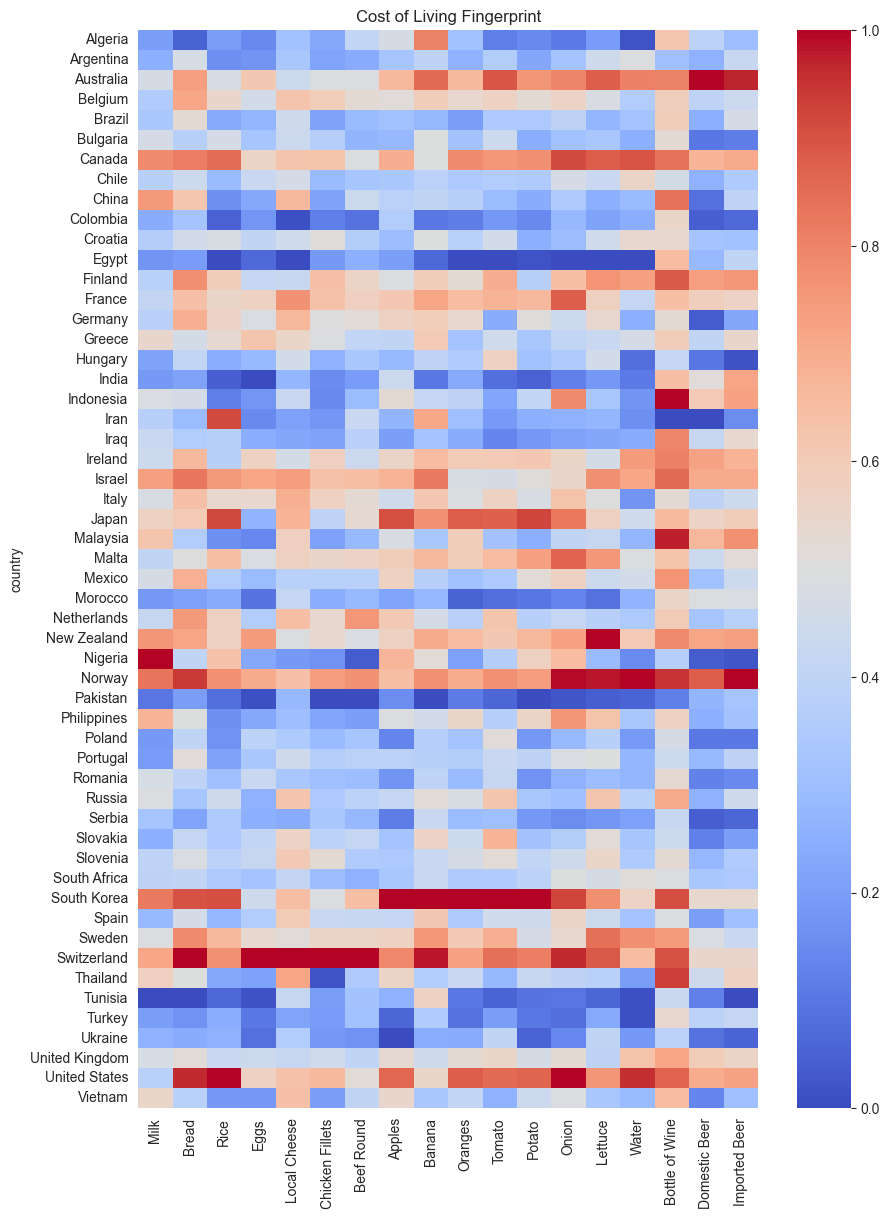

In [215]:
from sklearn.preprocessing import MinMaxScaler


heatmap_data = grocery_df_imputed.groupby('country')[feature_names].median()

minmax_scalar = MinMaxScaler()
df_scaled = pd.DataFrame(
    minmax_scalar.fit_transform(heatmap_data),
    columns=feature_names,
    index=heatmap_data.index
)
plt.figure(figsize=(10, 14))
sns.heatmap(df_scaled, cmap='coolwarm', annot=False)
plt.title('Cost of Living Fingerprint')
plt.show()


In [216]:
df_scaled.head(54)

,Milk,Bread,Rice,Eggs,Local Cheese,Chicken Fillets,Beef Round,Apples,Banana,Oranges,Tomato,Potato,Onion,Lettuce,Water,Bottle of Wine,Domestic Beer,Imported Beer
country,,,,,,,,,,,,,,,,,,
Algeria,0.200230,0.052881,0.197678,0.145713,0.310036,0.227051,0.408082,0.469206,0.803481,0.310888,0.117830,0.148189,0.109108,0.194843,0.018559,0.619550,0.389605,0.300512
Argentina,0.250311,0.476474,0.159133,0.174126,0.328425,0.217687,0.236504,0.323236,0.390889,0.258763,0.362535,0.225802,0.318182,0.446406,0.495059,0.305250,0.260663,0.424144
Australia,0.471741,0.735741,0.472943,0.609688,0.440464,0.495183,0.495937,0.662062,0.852785,0.663677,0.893387,0.758632,0.798498,0.877408,0.806368,0.803936,1.000000,0.971933
Belgium,0.352583,0.715000,0.548820,0.459979,0.628302,0.593045,0.528960,0.515470,0.586098,0.542323,0.569326,0.524867,0.565033,0.483336,0.358354,0.582793,0.397452,0.437226
Brazil,0.336396,0.527632,0.232323,0.272227,0.447245,0.213246,0.288784,0.310285,0.280427,0.196314,0.342396,0.340846,0.391226,0.269588,0.316593,0.588663,0.253873,0.467011
Bulgaria,0.466014,0.374520,0.468609,0.325128,0.436454,0.369653,0.268419,0.279725,0.498239,0.314000,0.441583,0.245308,0.309370,0.328882,0.250913,0.527012,0.101280,0.116686
Canada,0.782593,0.811076,0.850357,0.560489,0.627670,0.629926,0.495721,0.697190,0.498239,0.782948,0.755047,0.776141,0.911774,0.881352,0.898208,0.837800,0.678689,0.706395
Chile,0.372987,0.438102,0.285824,0.429651,0.468544,0.288529,0.326372,0.337416,0.385761,0.342702,0.355478,0.348748,0.466257,0.426575,0.558447,0.464326,0.257235,0.348801
China,0.749402,0.617895,0.160902,0.226784,0.660656,0.210976,0.439007,0.386032,0.401224,0.374044,0.292825,0.240485,0.351456,0.249636,0.287878,0.837800,0.083793,0.397429


<Axes: title={'center': 'Feature Importance F-Score'}, xlabel='Feature', ylabel='F_Score'>

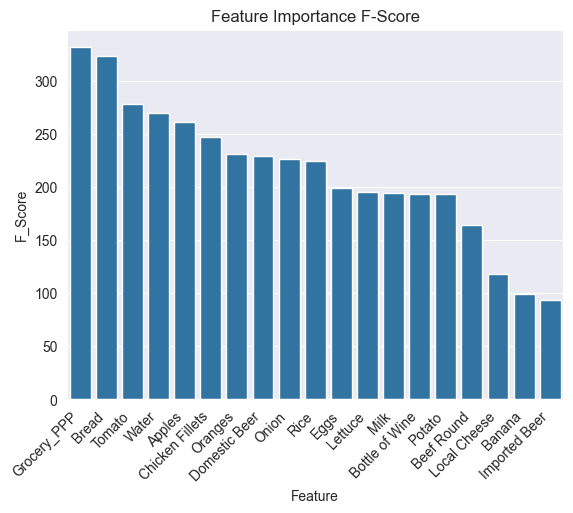

In [225]:
from sklearn.feature_selection import SelectKBest, f_classif

X = grocery_df_imputed[feature_names]
Y = grocery_df_imputed['country']

kselector = SelectKBest(score_func=f_classif)
kselector.fit(X,Y)
f_scores = kselector.scores_

feature_importance = pd.DataFrame ({
    'Feature': feature_names,
    'F_Score': f_scores
})
feature_importance = feature_importance.sort_values(by='F_Score', ascending=False)

plt.xticks(rotation=45, ha='right')
plt.title('Feature Importance F-Score')
sns.barplot(x=feature_importance['Feature'], y=feature_importance['F_Score'])


# #Relationship Check

In [226]:
print (feature_importance)

            Feature     F_Score
18      Grocery_PPP  331.565040
1             Bread  323.752505
10           Tomato  278.301323
14            Water  269.686990
7            Apples  261.241428
5   Chicken Fillets  246.765766
9           Oranges  231.055522
16    Domestic Beer  229.239908
12            Onion  226.442624
2              Rice  224.569774
3              Eggs  199.198943
13          Lettuce  195.630667
0              Milk  194.199981
15   Bottle of Wine  193.364686
11           Potato  193.001473
6        Beef Round  164.362285
4      Local Cheese  118.271622
8            Banana   99.509844
17    Imported Beer   94.081540


In [227]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X, Y, discrete_features=False, random_state=54)

mi_results = pd.DataFrame({
    'Feature': feature_names,
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

print(mi_results)

            Feature  MI_Score
15   Bottle of Wine  1.823823
10           Tomato  1.357208
7            Apples  1.319390
1             Bread  1.313111
5   Chicken Fillets  1.291989
9           Oranges  1.289285
12            Onion  1.287720
6        Beef Round  1.242617
16    Domestic Beer  1.217547
2              Rice  1.214025
14            Water  1.209839
11           Potato  1.207951
13          Lettuce  1.152966
4      Local Cheese  1.087672
3              Eggs  1.079612
18      Grocery_PPP  1.077390
17    Imported Beer  1.042650
8            Banana  1.016178
0              Milk  1.002403


# #Feature Engineering


In [220]:
usd_df = grocery_df_imputed.copy()
usd_df[feature_names] = robust_scaler.inverse_transform(usd_df[feature_names])
usd_df[feature_names] = np.expm1(usd_df[feature_names])


usd_df['Total_Basket'] = usd_df[feature_names].sum(axis=1)


usa_baseline = usd_df[usd_df['country'] == 'United States']['Total_Basket'].median()

usd_df['Grocery_Price_Index'] = usd_df['Total_Basket'] / usa_baseline


grocery_df_imputed['Grocery_Price_Index'] = usd_df['Grocery_Price_Index']

feature_names = [
    'Milk', 'Bread', 'Rice', 'Eggs', 'Local Cheese',
    'Chicken Fillets', 'Beef Round', 'Apples', 'Banana',
    'Oranges', 'Tomato', 'Potato', 'Onion', 'Lettuce',
    'Water', 'Bottle of Wine', 'Domestic Beer', 'Imported Beer',
    'Grocery_Price_Index'
]

In [221]:
print(grocery_df_imputed[feature_names].skew())


Milk               0.852494
Bread              0.151218
Rice               0.613347
Eggs               0.039969
Local Cheese      -0.278961
Chicken Fillets    0.102243
Beef Round         0.079381
Apples             0.277453
Banana             0.524148
Oranges            0.434002
Tomato             0.049385
Potato             0.515044
Onion              0.441352
Lettuce            0.162008
Water              0.533181
Bottle of Wine    -0.472690
Domestic Beer      0.188311
Imported Beer      0.139006
Grocery_PPP        0.777349
dtype: float64
